<a href="https://colab.research.google.com/github/Archangel4148/STAT-4210-Final-Project/blob/master/Final_Lasso_Ridge_Linear_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
# pip install ISLP

In [120]:
# path='/content/drive/MyDrive/Colab Notebooks/'

In [121]:
# from google.colab import drive
# drive.mount('/content/drive')

In [122]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [123]:
import statsmodels.api as sm

In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [125]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [126]:
# StudentDepression = load_data("/content/drive/MyDrive/Colab Notebooks/Student Depression Dataset")
StudentDepression = load_data("d:\\Programming\\Classwork\\STAT4210\\STAT-4210-Final-Project\\dataset")
StudentDepression.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

#Ordinary Least Squares Mulitiple Linear Regression

In [127]:
terms = StudentDepression.columns.drop(['Depression', 'City', 'id', 'Gender', 'Profession', 'Degree'])
# terms = StudentDepression.columns.drop(['City', 'id', 'Gender', 'Profession', 'Degree'])
terms

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness'],
      dtype='str')

In [128]:
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype in ('object', 'string')]

StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].astype('category').cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].astype('category').cat.remove_unused_categories()

StudentDepression_processed = StudentDepression_processed.dropna()

y = StudentDepression_processed['Depression']
X = MS(terms).fit_transform(StudentDepression_processed)

model = sm.OLS(y, X)
results = model.fit()

In [129]:
StudentDepression['Dietary Habits'].unique()

<StringArray>
['Healthy', 'Moderate', 'Unhealthy', 'Others']
Length: 4, dtype: str

In [130]:
StudentDepression['Sleep Duration'].unique()

<StringArray>
['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours', 'Others']
Length: 5, dtype: str

###Ordinary Least Squares Regression Coefficients

In [131]:
# Identify object columns in the StudentDepression DataFrame that are in 'terms'
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype in ('object', 'string')]

# Create a copy of the DataFrame and convert identified object columns to 'category' dtype
StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

# Filter out 'Others' from 'Sleep Duration' and 'Dietary Habits'
StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

# Remove unused categories after filtering
StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].cat.remove_unused_categories()

# Drop rows with any missing values from the processed DataFrame
StudentDepression_processed = StudentDepression_processed.dropna()

# Ensure 'y' aligns with the processed DataFrame after dropping NaNs
y = StudentDepression_processed['Depression']

# Now apply ModelSpec to the processed dataframe
X = MS(terms).fit_transform(StudentDepression_processed)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0357,0.019,-1.861,0.063
Age,-0.0132,0.000,-31.184,0.000
Academic Pressure,0.1087,0.002,69.612,0.000
Work Pressure,0.0282,0.073,0.385,0.700
CGPA,0.0071,0.001,5.073,0.000
Study Satisfaction,-0.0292,0.002,-19.182,0.000
Job Satisfaction,0.0297,0.072,0.410,0.682
Sleep Duration[7-8 hours],0.0045,0.006,0.757,0.449
Sleep Duration[Less than 5 hours],0.0404,0.006,7.017,0.000
Sleep Duration[More than 8 hours],-0.0318,0.006,-5.126,0.000


###Ordinary Least Squares Significant Coefficients

In [132]:
terms = StudentDepression.columns.drop(['Depression', 'Job Satisfaction', 'City', 'id', 'Gender', 'Profession', 'Degree', 'Work Pressure'])

In [133]:
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype in ('object', 'string')]

StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

# Filter out 'Others' from 'Sleep Duration' and 'Dietary Habits'
StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

# Remove unused categories after filtering
StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].astype('category').cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].astype('category').cat.remove_unused_categories()

StudentDepression_processed = StudentDepression_processed.dropna()

y = StudentDepression_processed['Depression']

X = MS(terms).fit_transform(StudentDepression_processed)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0346,0.019,-1.807,0.071
Age,-0.0132,0.000,-31.185,0.000
Academic Pressure,0.1086,0.002,69.609,0.000
CGPA,0.0070,0.001,5.014,0.000
Study Satisfaction,-0.0293,0.002,-19.223,0.000
Sleep Duration[7-8 hours],0.0045,0.006,0.760,0.447
Sleep Duration[Less than 5 hours],0.0404,0.006,7.013,0.000
Sleep Duration[More than 8 hours],-0.0318,0.006,-5.133,0.000
Dietary Habits[Moderate],0.0617,0.005,11.819,0.000
Dietary Habits[Unhealthy],0.1319,0.005,25.248,0.000


### 95% Confidence Intervals for Coefficients

In [134]:
print('OLS Regression Coefficients 95% Confidence Intervals:')
display(results.conf_int(alpha=0.05))

OLS Regression Coefficients 95% Confidence Intervals:


,0,1
intercept,-0.072109,0.002934
Age,-0.014012,-0.012355
Academic Pressure,0.105569,0.111686
CGPA,0.004265,0.009741
Study Satisfaction,-0.032239,-0.026273
Sleep Duration[7-8 hours],-0.007098,0.016083
Sleep Duration[Less than 5 hours],0.029097,0.051668
Sleep Duration[More than 8 hours],-0.044001,-0.019684
Dietary Habits[Moderate],0.051456,0.071916
Dietary Habits[Unhealthy],0.121615,0.142087


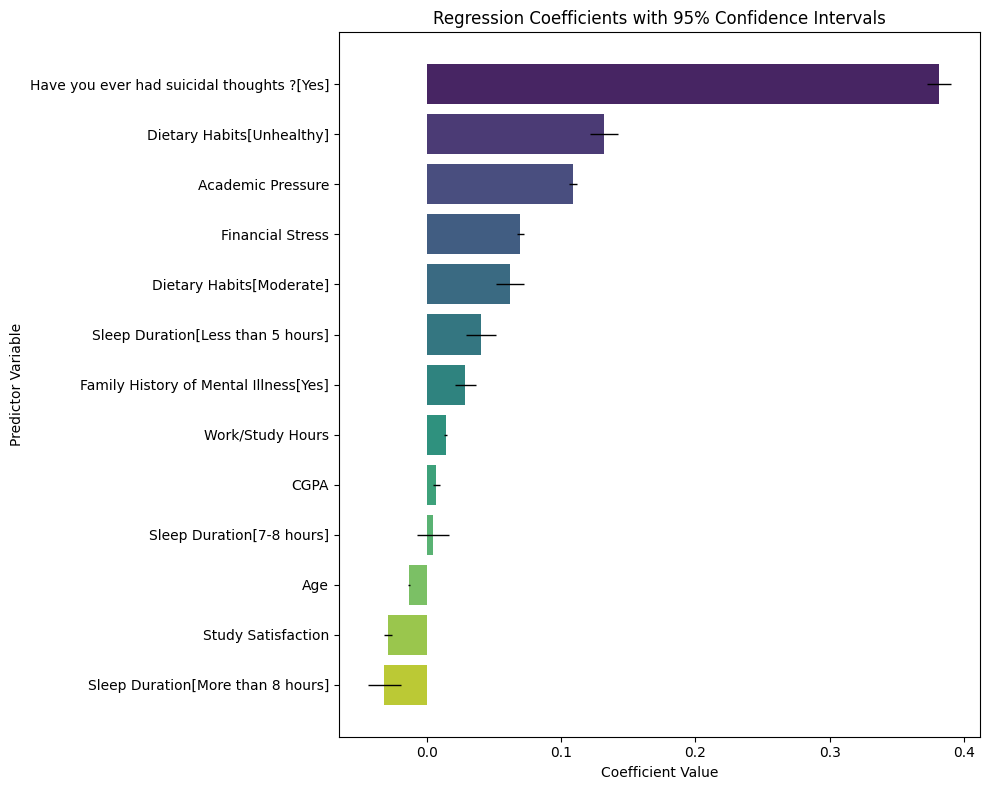

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the coefficients and their confidence intervals
coefs = results.params
conf_int = results.conf_int(alpha=0.05)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'predictor': coefs.index,
    'coefficient': coefs.values,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

# Exclude the intercept from the plot for better visualization of predictors
coef_df = coef_df[coef_df['predictor'] != 'intercept']

# Sort by coefficient value for better readability
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='coefficient', y='predictor', data=coef_df, palette='viridis', hue='predictor', legend=False, ax=ax)

# Add error bars for confidence intervals
for idx, row in coef_df.iterrows():
    ax.hlines(row['predictor'], row['lower_ci'], row['upper_ci'], color='black', linewidth=1)

ax.set_title('Regression Coefficients with 95% Confidence Intervals')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Variable')
plt.tight_layout()
plt.show()

### 95% Prediction Intervals for Coefficients

Sample of OLS Predictions with 95% Prediction Intervals:


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,0.571156,0.008789,0.553929,0.588382,-0.100045,1.242357
1,0.033116,0.007683,0.018057,0.048175,-0.638032,0.704265
2,0.051110,0.007524,0.036363,0.065858,-0.620031,0.722252
3,0.783467,0.007341,0.769078,0.797856,0.112333,1.454601
4,0.566326,0.007746,0.551144,0.581507,-0.104826,1.237477


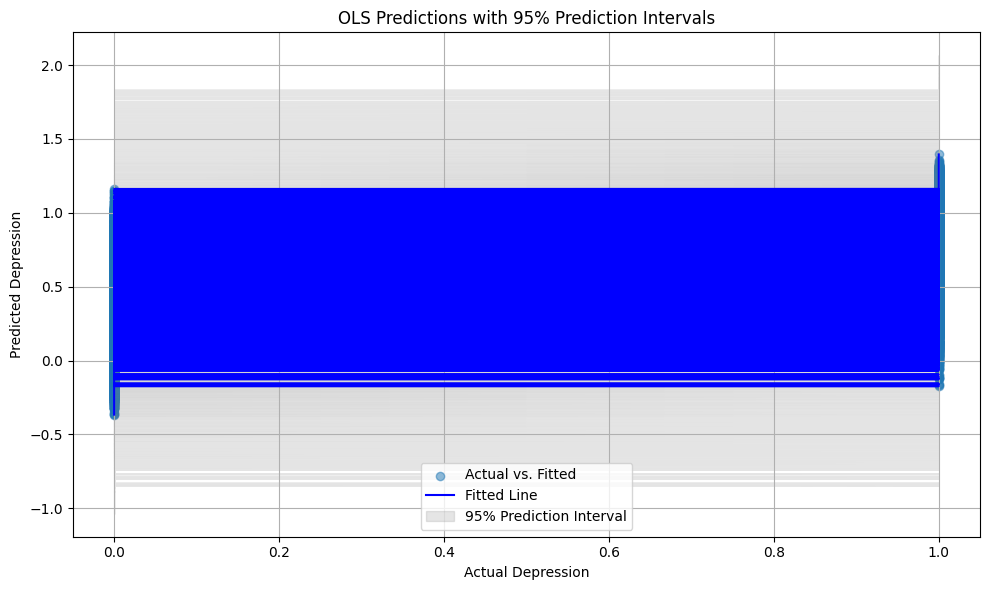

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions and prediction intervals for the OLS model
predictions_summary_frame = results.get_prediction(X).summary_frame(alpha=0.05)

# Display a sample of the prediction intervals
print("Sample of OLS Predictions with 95% Prediction Intervals:")
display(predictions_summary_frame.head())

# You can also visualize these if desired, for example, on a scatter plot of observed vs. fitted values
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y, results.fittedvalues, alpha=0.5, label='Actual vs. Fitted')

# Plot prediction intervals for a subset of the data for clarity
# For better visualization, we might sort by fitted values or use a more sophisticated plot
ordered_indices = np.argsort(results.fittedvalues)

ax.plot(y.iloc[ordered_indices], predictions_summary_frame['mean'].iloc[ordered_indices], color='blue', label='Fitted Line')
ax.fill_between(y.iloc[ordered_indices],
                predictions_summary_frame['obs_ci_lower'].iloc[ordered_indices],
                predictions_summary_frame['obs_ci_upper'].iloc[ordered_indices],
                color='gray', alpha=0.2, label='95% Prediction Interval')

ax.set_xlabel('Actual Depression')
ax.set_ylabel('Predicted Depression')
ax.set_title('OLS Predictions with 95% Prediction Intervals')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Varinace Inflation Factor (VIF)

In [137]:
vif = pd.DataFrame({'predictor': X.columns, 'VIF': [VIF(X.values, i) for i in range(X.shape[1])]})
display(vif)

,predictor,VIF
0,intercept,87.145693
1,Age,1.022766
2,Academic Pressure,1.105429
3,CGPA,1.003364
4,Study Satisfaction,1.020297
5,Sleep Duration[7-8 hours],1.613631
6,Sleep Duration[Less than 5 hours],1.649234
7,Sleep Duration[More than 8 hours],1.554041
8,Dietary Habits[Moderate],1.484706
9,Dietary Habits[Unhealthy],1.511552


### Residual Analysis

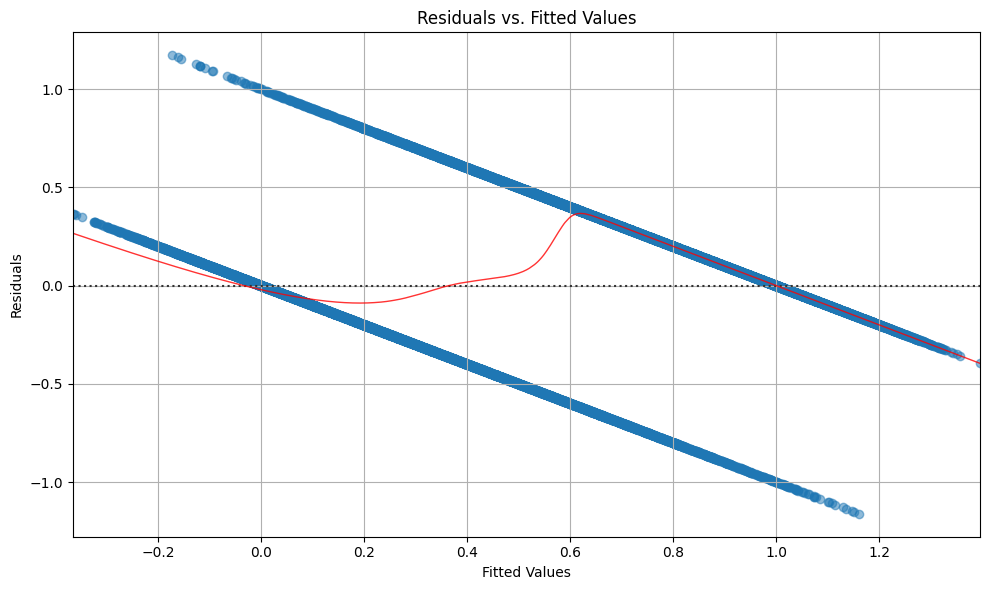

In [138]:
# Plotting residuals vs. fitted values
fig, ax = plt.subplots(figsize=(10, 6))
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=ax,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax.set_title('Residuals vs. Fitted Values')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

###Robust Covariance Estimation

In [139]:
results_robust = results.get_robustcov_results(cov_type='HC3')
print(results_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             Depression   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     4887.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:02   Log-Likelihood:                -9661.9
No. Observations:               27868   AIC:                         1.935e+04
Df Residuals:                   27854   BIC:                         1.947e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

###Q-Q Plot

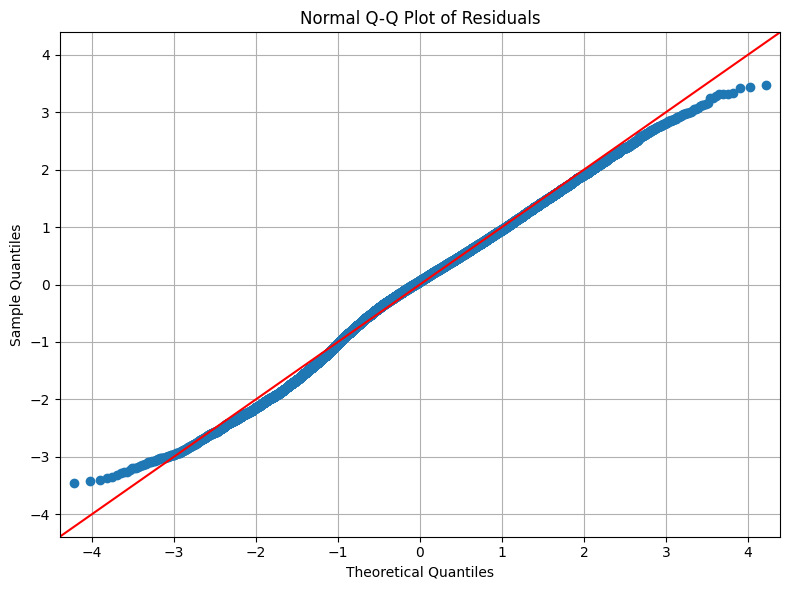

In [140]:
import statsmodels.api as sm
import scipy.stats as stats

# Q-Q plot of standardized residuals
fig, ax = plt.subplots(figsize=(8, 6))
res = results.resid # residuals
probplot = sm.ProbPlot(res, stats.t, fit=True)
probplot.qqplot(line='45', ax=ax)
ax.set_title('Normal Q-Q Plot of Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

###Cross-Validation

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the OLS model on the training data
ols_model_cv = sm.OLS(y_train, X_train)
ols_results_cv = ols_model_cv.fit()

# Make predictions on the test set
ols_predictions_test = ols_results_cv.predict(X_test)

# Evaluate the model on the test set
ols_mse_cv = mean_squared_error(y_test, ols_predictions_test)
ols_rmse_cv = np.sqrt(ols_mse_cv)
ols_mae_cv = mean_absolute_error(y_test, ols_predictions_test)
ols_r2_cv = r2_score(y_test, ols_predictions_test)

# Display the evaluation metrics
print(f"OLS Model Cross-Validation Metrics (Test Set):\n")
print(f"  R-squared: {ols_r2_cv:.4f}")
print(f"  Mean Squared Error (MSE): {ols_mse_cv:.4f}")
print(f"  Root Mean Squared Error (RMSE): {ols_rmse_cv:.4f}")
print(f"  Mean Absolute Error (MAE): {ols_mae_cv:.4f}")

OLS Model Cross-Validation Metrics (Test Set):

  R-squared: 0.5211
  Mean Squared Error (MSE): 0.1158
  Root Mean Squared Error (RMSE): 0.3404
  Mean Absolute Error (MAE): 0.2656


# Ridge Regression

In [142]:
import sklearn.linear_model as skl
import numpy as np

# Drop the intercept column before scaling the features
X_for_elasticnet = X.drop(columns=['intercept'])

# Center and scale the features
Xs = X_for_elasticnet - X_for_elasticnet.mean(0).to_numpy()[None,:]
X_scale = X_for_elasticnet.std(0).to_numpy().copy()

# Handle potential division by zero if a feature has zero standard deviation
X_scale[X_scale == 0] = 1

Xs = Xs / X_scale[None,:]

lambdas = 10**np.linspace(8, -2, 100) / y.std()
soln_array = skl.ElasticNet.path(Xs,
                                 y,
                                 l1_ratio=0.,
                                 alphas=lambdas
                                 )[1]
print(soln_array.shape)

C:\Users\archa\AppData\Local\Temp\ipykernel_11008\1454652349.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  Xs = X_for_elasticnet - X_for_elasticnet.mean(0).to_numpy()[None,:]
C:\Users\archa\AppData\Local\Temp\ipykernel_11008\1454652349.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  X_scale = X_for_elasticnet.std(0).to_numpy().copy()
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterat

(13, 100)


d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.159e+03, tolerance: 1.632e+00
  model = cd_fast.enet_coordinate_descent_gram(
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consid

In [143]:
from sklearn.linear_model import RidgeCV

# Define a range of alpha values (lambdas) for RidgeCV to search over.
# It's good practice to use a logarithmic scale for alpha.
# The `lambdas` array from before can be used, or a new one can be generated.
alphas = 10**np.linspace(-2, 8, 100) # scikit-learn uses alpha instead of lambda

# Initialize RidgeCV model. cv=None uses Leave-One-Out Cross-Validation by default.
# We set store_cv_results=True to inspect the mean squared errors for each alpha.
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True, scoring='neg_mean_squared_error')

# Fit the model to the scaled features and target variable
ridge_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha): {ridge_cv.alpha_:.4f}")

Optimal regularization parameter (alpha): 34.3047


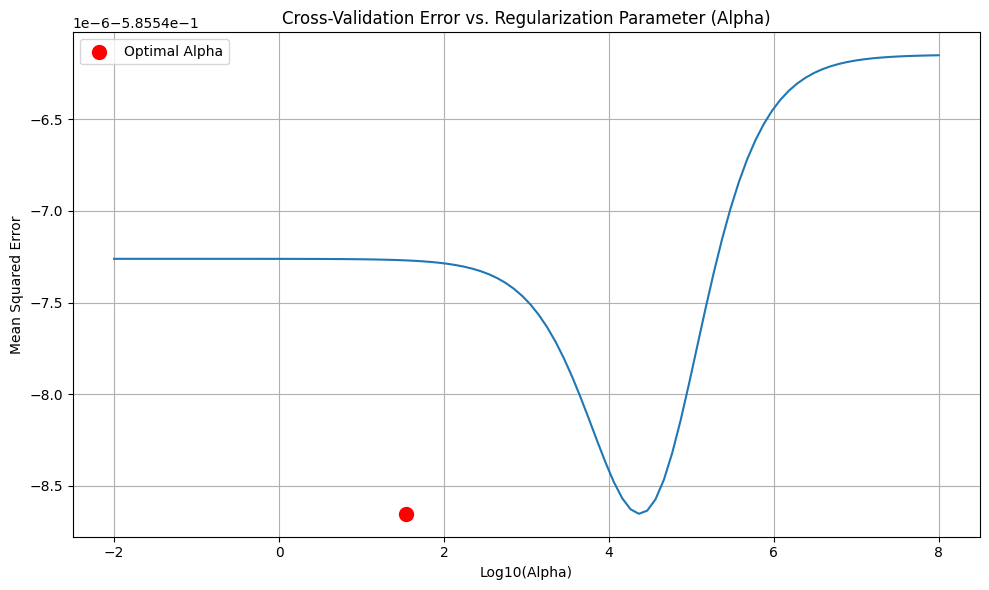

In [144]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
# For RidgeCV, when store_cv_results=True, cv_results_ directly holds the scores
# for each alpha across folds/samples. We need to average them.
mse_per_alpha = -ridge_cv.cv_results_.mean(axis=0)

# Plot the mean squared error as a function of alpha (lambda)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(ridge_cv.alphas), mse_per_alpha)
ax.scatter(np.log10(ridge_cv.alpha_), min(mse_per_alpha), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [145]:
optimal_alpha_ridge = ridge_cv.alpha_
optimal_ridge_model = skl.Ridge(alpha=optimal_alpha_ridge)
optimal_ridge_model.fit(Xs, y)

# Get the coefficients and feature names
ridge_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Ridge Regression Coefficients (alpha={optimal_alpha_ridge:.4f}):")
display(ridge_coefficients)

Optimal Ridge Regression Coefficients (alpha=34.3047):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183698
1,Academic Pressure,0.149962
11,Financial Stress,0.099996
8,Dietary Habits[Unhealthy],0.063554
10,Work/Study Hours,0.052281
7,Dietary Habits[Moderate],0.029429
5,Sleep Duration[Less than 5 hours],0.018459
12,Family History of Mental Illness[Yes],0.014273
2,CGPA,0.010286
4,Sleep Duration[7-8 hours],0.001976


<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\archa\AppData\Local\Temp\ipykernel_11008\3750770349.py:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_xlabel('Log($\lambda$)')


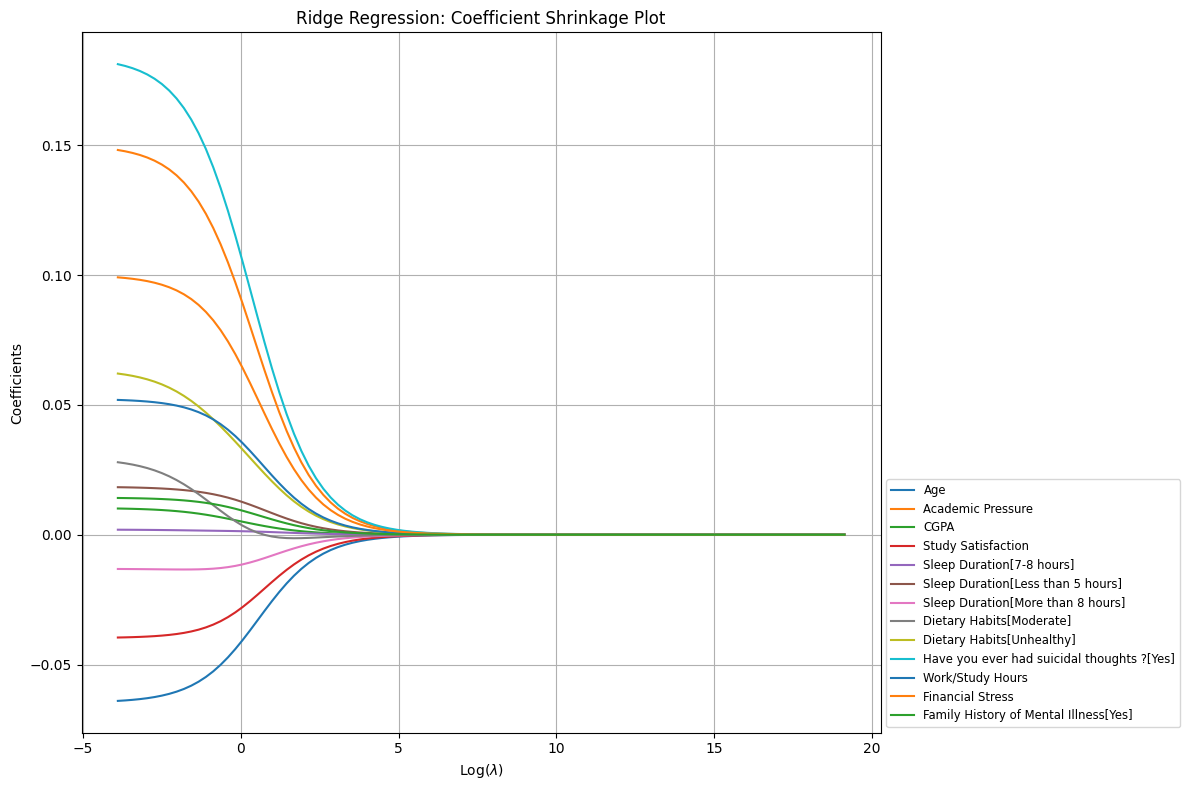

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure Xs.columns is available for labels
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array.shape[0]):
    ax.plot(np.log(lambdas), soln_array[i], label=feature_names[i])

ax.set_xlabel('Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title('Ridge Regression: Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

# Lasso Regression

In [147]:
from sklearn.linear_model import LassoCV

# Define a range of alpha values for LassoCV to search over.
# `n_alphas` specifies the number of alphas along the regularization path.
# `cv` specifies the cross-validation splitting strategy.
# `random_state` for reproducibility.
lasso_cv = LassoCV(alphas=None, cv=10, random_state=42, n_jobs=-1, max_iter=10000)

# Fit the model to the scaled features and target variable
lasso_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha) for Lasso: {lasso_cv.alpha_:.4f}")

d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Optimal regularization parameter (alpha) for Lasso: 0.0003


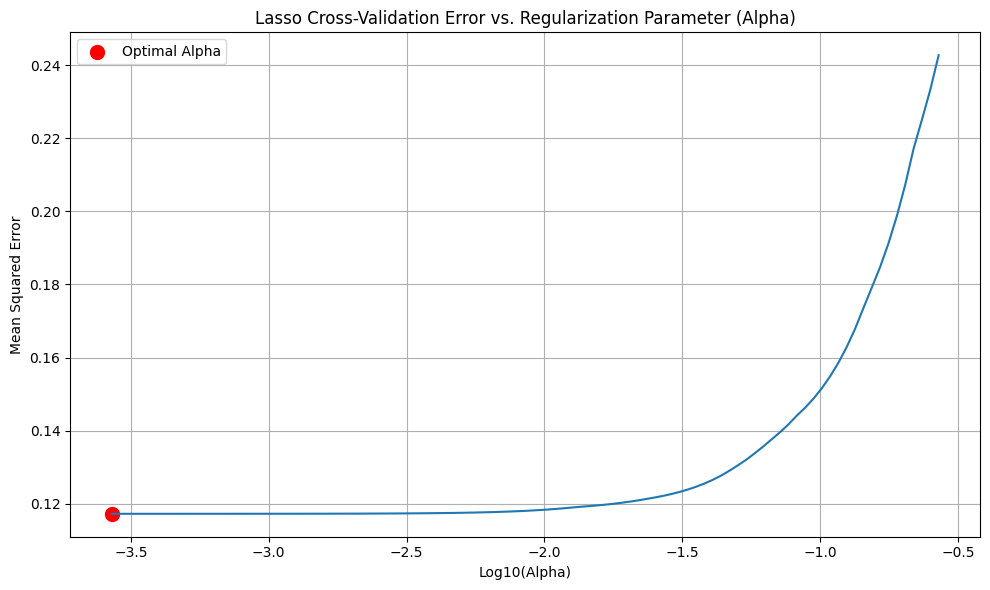

In [148]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
mse_per_alpha_lasso = lasso_cv.mse_path_.mean(axis=1)

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(lasso_cv.alphas_), mse_per_alpha_lasso)
ax.scatter(np.log10(lasso_cv.alpha_), min(mse_per_alpha_lasso), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Lasso Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [149]:
optimal_alpha_lasso = lasso_cv.alpha_
optimal_lasso_model = skl.Lasso(alpha=optimal_alpha_lasso)
optimal_lasso_model.fit(Xs, y)

# Get the coefficients and feature names
lasso_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Lasso Regression Coefficients (alpha={optimal_alpha_lasso:.4f}):")
display(lasso_coefficients[lasso_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Lasso Regression Coefficients (alpha=0.0003):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183803
1,Academic Pressure,0.149957
11,Financial Stress,0.099904
8,Dietary Habits[Unhealthy],0.063103
10,Work/Study Hours,0.052106
7,Dietary Habits[Moderate],0.028928
5,Sleep Duration[Less than 5 hours],0.018039
12,Family History of Mental Illness[Yes],0.014024
2,CGPA,0.010039
4,Sleep Duration[7-8 hours],0.001540


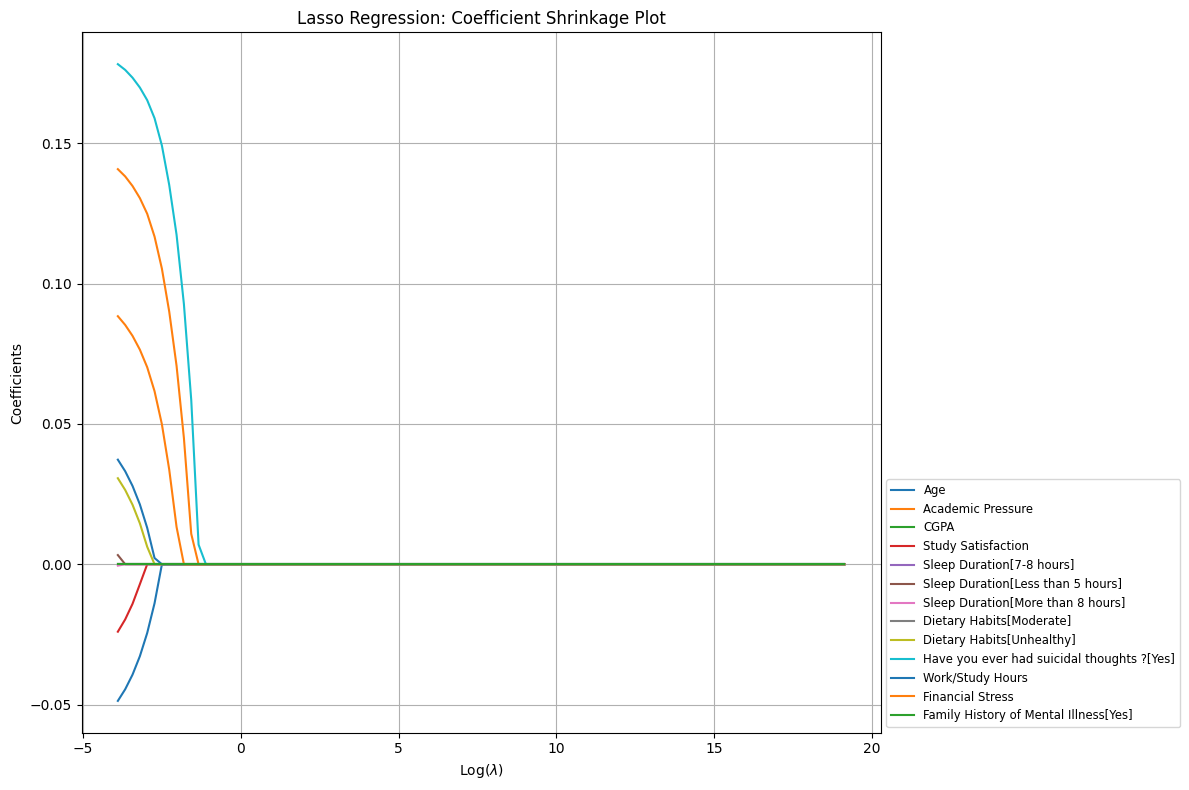

In [150]:
import sklearn.linear_model as skl
import numpy as np
import matplotlib.pyplot as plt

# Reuse Xs, y, and lambdas from previous steps
# Xs = X.drop(columns=['intercept'])
# Xs = (Xs - Xs.mean(0).to_numpy()[None,:]) / Xs.std(0).to_numpy()[None,:]
# lambdas = 10**np.linspace(8, -2, 100) / y.std()

# Compute the Lasso regularization path (l1_ratio=1.0 for Lasso)
soln_array_lasso = skl.ElasticNet.path(Xs,
                                      y,
                                      l1_ratio=1., # 1.0 for Lasso
                                      alphas=lambdas
                                      )[1]

# Ensure feature_names is available
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array_lasso.shape[0]):
    ax.plot(np.log(lambdas), soln_array_lasso[i], label=feature_names[i])

ax.set_xlabel(r'Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title('Lasso Regression: Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

# Elastic Net Regression

In [151]:
from sklearn.linear_model import ElasticNetCV

# Define a range of l1_ratio values to search over (0 for Ridge, 1 for Lasso)
l1_ratios = np.linspace(0.01, 1.0, 10)

# Initialize ElasticNetCV model. `alphas=None` means it will automatically choose a grid.
elastic_net_cv = ElasticNetCV(l1_ratio=l1_ratios,
                              cv=10,
                              random_state=42,
                              n_jobs=-1,
                              max_iter=10000)

# Fit the model to the scaled features and target variable
elastic_net_cv.fit(Xs, y)

# Display the optimal alpha and l1_ratio
print(f"Optimal alpha for Elastic Net: {elastic_net_cv.alpha_:.4f}")
print(f"Optimal l1_ratio for Elastic Net: {elastic_net_cv.l1_ratio_:.4f}")

Optimal alpha for Elastic Net: 0.0003
Optimal l1_ratio for Elastic Net: 1.0000


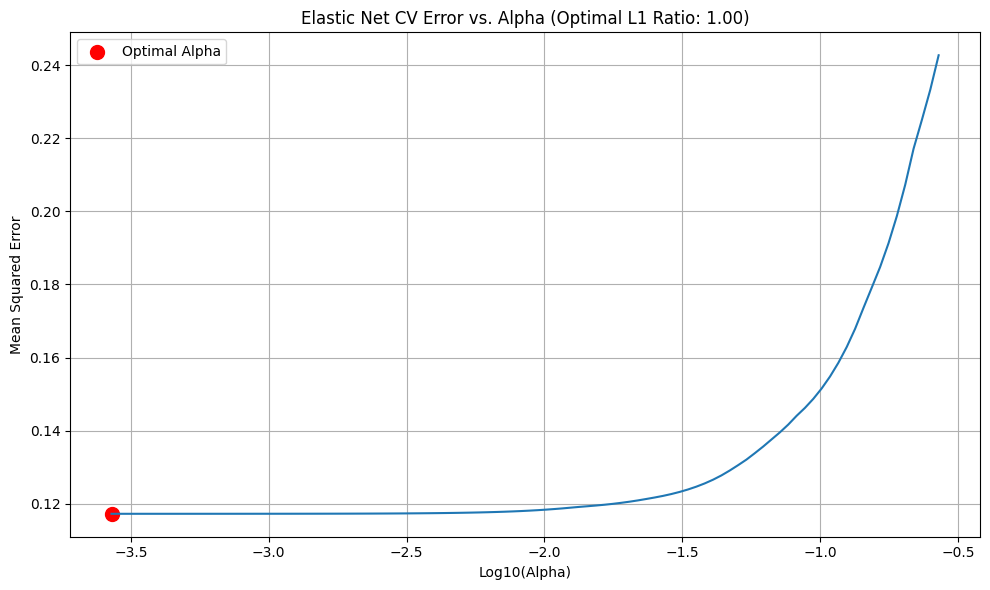

In [152]:
import matplotlib.pyplot as plt

# Get the index of the optimal l1_ratio
optimal_l1_ratio_idx = np.argmin(np.abs(elastic_net_cv.l1_ratio - elastic_net_cv.l1_ratio_))

# Extract the mean cross-validated errors for the optimal l1_ratio
mse_per_alpha_elastic_net = elastic_net_cv.mse_path_[optimal_l1_ratio_idx, :].mean(axis=1)

# Get the alphas corresponding to the optimal l1_ratio
alphas_for_plotting = elastic_net_cv.alphas_[optimal_l1_ratio_idx]

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(alphas_for_plotting), mse_per_alpha_elastic_net)
ax.scatter(np.log10(elastic_net_cv.alpha_), min(mse_per_alpha_elastic_net), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title(f'Elastic Net CV Error vs. Alpha (Optimal L1 Ratio: {elastic_net_cv.l1_ratio_:.2f})')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [153]:
import sklearn.linear_model as skl

optimal_alpha_elastic_net = elastic_net_cv.alpha_
optimal_l1_ratio_elastic_net = elastic_net_cv.l1_ratio_

optimal_elastic_net_model = skl.ElasticNet(alpha=optimal_alpha_elastic_net,
                                           l1_ratio=optimal_l1_ratio_elastic_net,
                                           max_iter=10000)
optimal_elastic_net_model.fit(Xs, y)

# Get the coefficients and feature names
elastic_net_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_elastic_net_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Elastic Net Regression Coefficients (alpha={optimal_alpha_elastic_net:.4f}, l1_ratio={optimal_l1_ratio_elastic_net:.4f}):")
display(elastic_net_coefficients[elastic_net_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Elastic Net Regression Coefficients (alpha=0.0003, l1_ratio=1.0000):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183803
1,Academic Pressure,0.149957
11,Financial Stress,0.099904
8,Dietary Habits[Unhealthy],0.063103
10,Work/Study Hours,0.052106
7,Dietary Habits[Moderate],0.028928
5,Sleep Duration[Less than 5 hours],0.018039
12,Family History of Mental Illness[Yes],0.014024
2,CGPA,0.010039
4,Sleep Duration[7-8 hours],0.001540


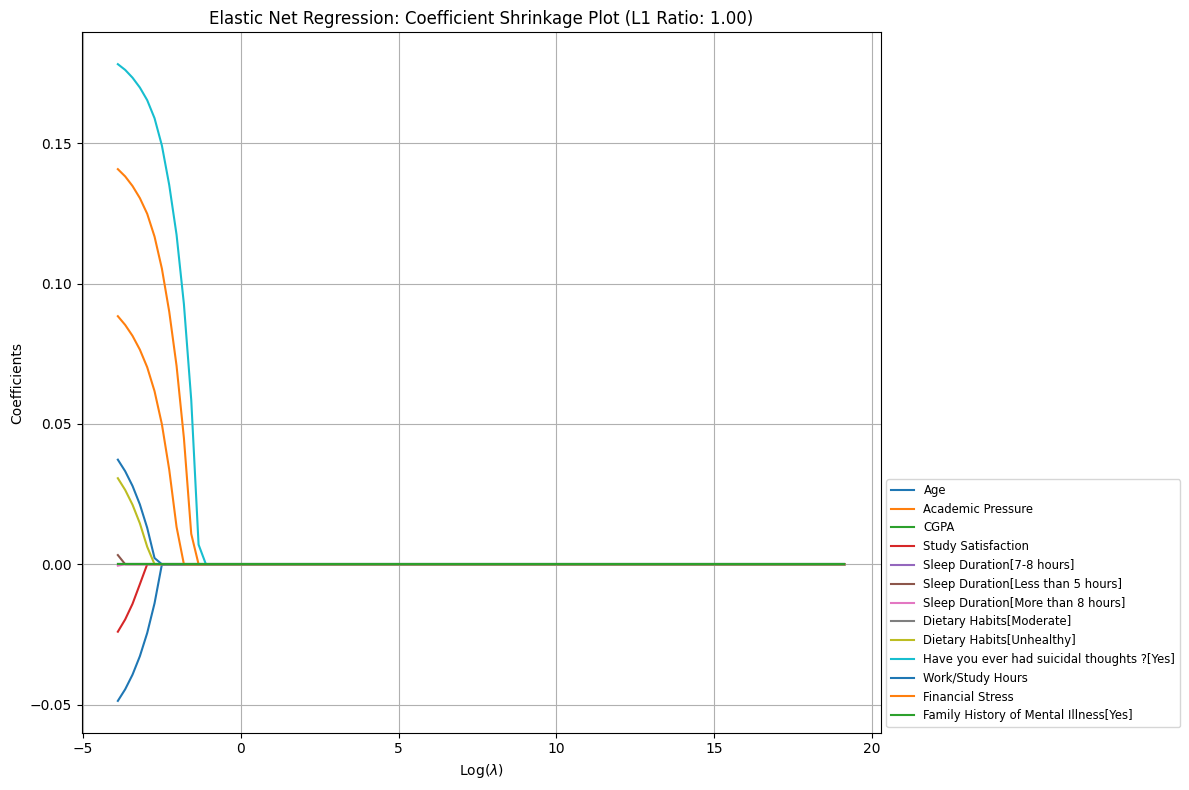

In [154]:
import sklearn.linear_model as skl
import numpy as np
import matplotlib.pyplot as plt

# Get the optimal l1_ratio from the ElasticNetCV result
optimal_l1_ratio_elastic_net = elastic_net_cv.l1_ratio_

# Compute the Elastic Net regularization path
soln_array_elastic_net = skl.ElasticNet.path(Xs,
                                              y,
                                              l1_ratio=optimal_l1_ratio_elastic_net,
                                              alphas=lambdas
                                             )[1]

# Ensure feature_names is available
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array_elastic_net.shape[0]):
    ax.plot(np.log(lambdas), soln_array_elastic_net[i], label=feature_names[i])

ax.set_xlabel(r'Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title(f'Elastic Net Regression: Coefficient Shrinkage Plot (L1 Ratio: {optimal_l1_ratio_elastic_net:.2f})')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

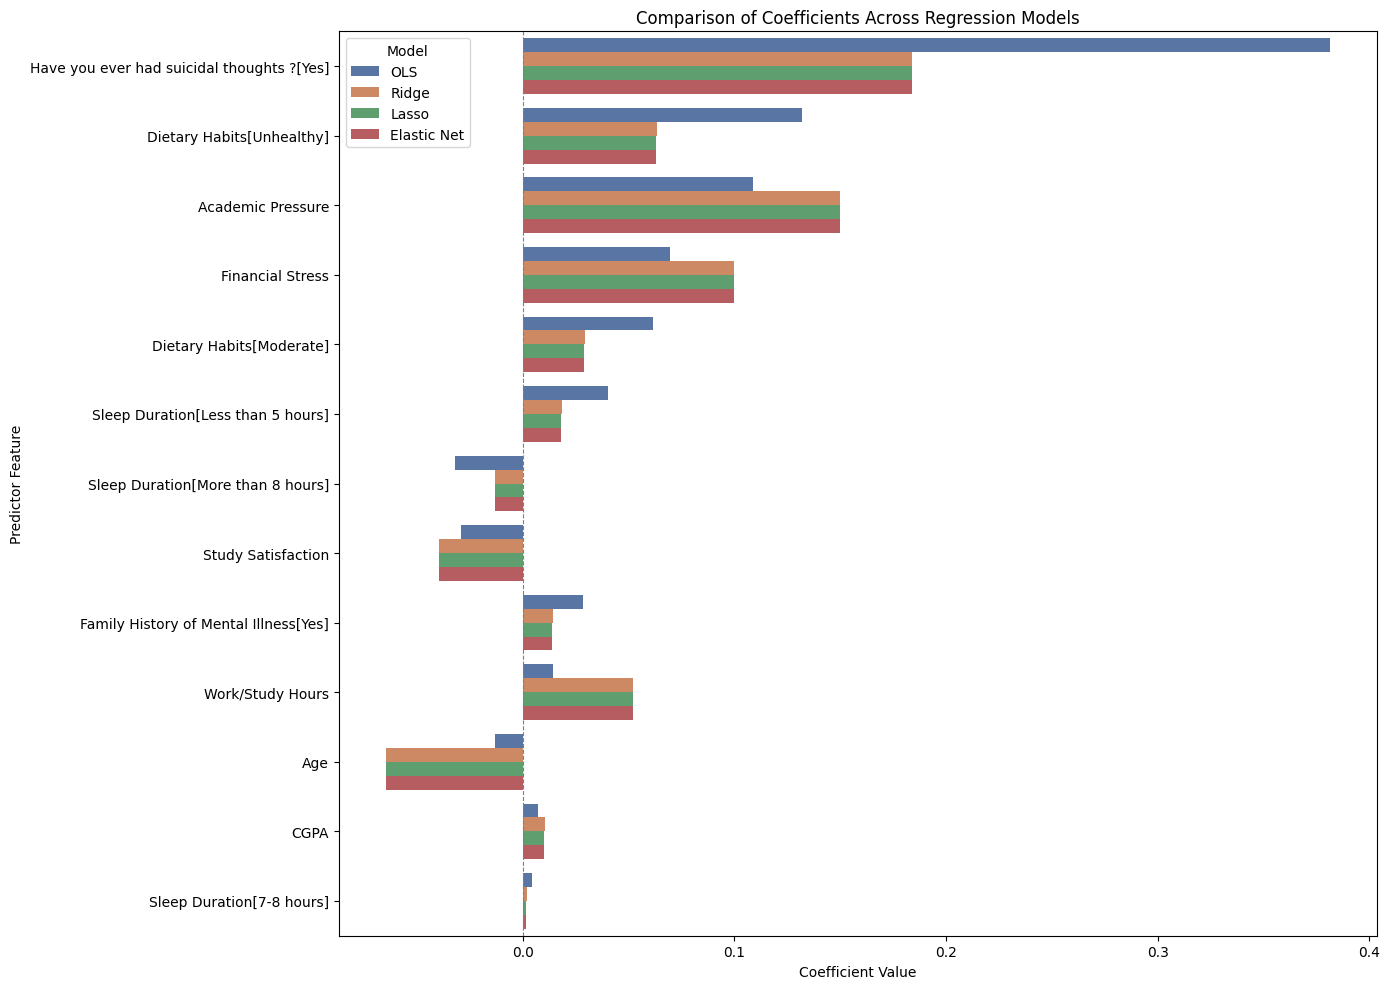

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare OLS coefficients (excluding intercept and aligning with scaled features)
ols_coefs_aligned = results.params[X_for_elasticnet.columns]
ols_coef_df_for_plot = pd.DataFrame({
    'Feature': ols_coefs_aligned.index,
    'Coefficient': ols_coefs_aligned.values,
    'Model': 'OLS'
})

# Prepare Ridge coefficients
ridge_coef_df_for_plot = pd.DataFrame({
    'Feature': ridge_coefficients['Feature'],
    'Coefficient': ridge_coefficients['Coefficient'],
    'Model': 'Ridge'
})

# Prepare Lasso coefficients
lasso_coef_df_for_plot = pd.DataFrame({
    'Feature': lasso_coefficients['Feature'],
    'Coefficient': lasso_coefficients['Coefficient'],
    'Model': 'Lasso'
})

# Prepare Elastic Net coefficients
elastic_net_coef_df_for_plot = pd.DataFrame({
    'Feature': elastic_net_coefficients['Feature'],
    'Coefficient': elastic_net_coefficients['Coefficient'],
    'Model': 'Elastic Net'
})

# Combine all coefficient DataFrames
all_coefs_df = pd.concat([
    ols_coef_df_for_plot,
    ridge_coef_df_for_plot,
    lasso_coef_df_for_plot,
    elastic_net_coef_df_for_plot
])

# Sort by absolute OLS coefficient for better visualization of importance
sorted_features = ols_coef_df_for_plot.reindex(ols_coef_df_for_plot['Coefficient'].abs().sort_values(ascending=False).index)['Feature']

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=all_coefs_df, palette='deep', order=sorted_features, ax=ax)

ax.set_title('Comparison of Coefficients Across Regression Models')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Feature')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Model')
plt.tight_layout()
plt.show()

In [156]:
import pandas as pd

# Reuse the individual coefficient DataFrames created for the comparison plot
# ols_coef_df_for_plot, ridge_coef_df_for_plot, lasso_coef_df_for_plot, elastic_net_coef_df_for_plot

# Rename 'Coefficient' column in each to reflect the model
ols_coefficients_renamed = ols_coef_df_for_plot.rename(columns={'Coefficient': 'OLS_Coefficient'}).drop(columns=['Model'])
ridge_coefficients_renamed = ridge_coef_df_for_plot.rename(columns={'Coefficient': 'Ridge_Coefficient'}).drop(columns=['Model'])
lasso_coefficients_renamed = lasso_coef_df_for_plot.rename(columns={'Coefficient': 'Lasso_Coefficient'}).drop(columns=['Model'])
elastic_net_coefficients_renamed = elastic_net_coef_df_for_plot.rename(columns={'Coefficient': 'ElasticNet_Coefficient'}).drop(columns=['Model'])

# Merge them all on 'Feature'
combined_coefficients = pd.merge(ols_coefficients_renamed, ridge_coefficients_renamed, on='Feature', how='outer')
combined_coefficients = pd.merge(combined_coefficients, lasso_coefficients_renamed, on='Feature', how='outer')
combined_coefficients = pd.merge(combined_coefficients, elastic_net_coefficients_renamed, on='Feature', how='outer')

# Sort by OLS_Coefficient for better readability
combined_coefficients = combined_coefficients.sort_values(by='OLS_Coefficient', ascending=False)

print("Comparison of Coefficients Across All Models:")
display(combined_coefficients)

Comparison of Coefficients Across All Models:


,Feature,OLS_Coefficient,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
7,Have you ever had suicidal thoughts ?[Yes],0.381418,0.183698,0.183803,0.183803
4,Dietary Habits[Unhealthy],0.131851,0.063554,0.063103,0.063103
0,Academic Pressure,0.108627,0.149962,0.149957,0.149957
6,Financial Stress,0.069614,0.099996,0.099904,0.099904
3,Dietary Habits[Moderate],0.061686,0.029429,0.028928,0.028928
9,Sleep Duration[Less than 5 hours],0.040383,0.018459,0.018039,0.018039
5,Family History of Mental Illness[Yes],0.028577,0.014273,0.014024,0.014024
12,Work/Study Hours,0.014109,0.052281,0.052106,0.052106
2,CGPA,0.007003,0.010286,0.010039,0.010039
8,Sleep Duration[7-8 hours],0.004493,0.001976,0.001540,0.001540


In [158]:
# ── Define missing variables needed for AIC / BIC / Cp ───────────────────────
from sklearn.metrics import mean_squared_error

# Ridge MSE (on the full scaled dataset)
ridge_mse = mean_squared_error(y, optimal_ridge_model.predict(Xs))

# Lasso MSE + non-zero coefficient count
lasso_mse          = mean_squared_error(y, optimal_lasso_model.predict(Xs))
lasso_non_zero_coef = int(np.sum(optimal_lasso_model.coef_ != 0))

# Elastic Net MSE + non-zero coefficient count
elastic_net_mse          = mean_squared_error(y, optimal_elastic_net_model.predict(Xs))
elastic_net_non_zero_coef = int(np.sum(optimal_elastic_net_model.coef_ != 0))

# OLS MSE (using the same full dataset for consistency)
ols_mse = mean_squared_error(y, results.fittedvalues)

# performance_metrics DataFrame (baseline — AIC/BIC/Cp will be added to this below)
performance_metrics = pd.DataFrame(
    index=['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    columns=['R2', 'MSE', 'RMSE', 'MAE', 'AIC', 'BIC', 'Cp'],
    dtype=float
)

# Populate R2 / MSE / RMSE / MAE from the CV results already computed above
from sklearn.metrics import r2_score, mean_absolute_error

for model_name, model_obj, preds in [
    ('OLS',         None,                      results.fittedvalues),
    ('Ridge',       optimal_ridge_model,        optimal_ridge_model.predict(Xs)),
    ('Lasso',       optimal_lasso_model,        optimal_lasso_model.predict(Xs)),
    ('Elastic Net', optimal_elastic_net_model,  optimal_elastic_net_model.predict(Xs)),
]:
    mse  = mean_squared_error(y, preds)
    performance_metrics.loc[model_name, 'R2']   = r2_score(y, preds)
    performance_metrics.loc[model_name, 'MSE']  = mse
    performance_metrics.loc[model_name, 'RMSE'] = np.sqrt(mse)
    performance_metrics.loc[model_name, 'MAE']  = mean_absolute_error(y, preds)

In [159]:
N_obs = len(y)

# Calculate BIC for OLS
ols_bic = N_obs * np.log(ols_mse_cv) + (results.df_model + 1) * np.log(N_obs) # +1 for intercept

# Calculate BIC for Ridge
ridge_bic = N_obs * np.log(ridge_mse) + Xs.shape[1] * np.log(N_obs)

# Calculate BIC for Lasso
lasso_bic = N_obs * np.log(lasso_mse) + lasso_non_zero_coef * np.log(N_obs)

# Calculate BIC for Elastic Net
elastic_net_bic = N_obs * np.log(elastic_net_mse) + elastic_net_non_zero_coef * np.log(N_obs)

# Calculate AIC for OLS
ols_aic = N_obs * np.log(ols_mse) + 2 * (results.df_model + 1)

# Calculate AIC for Ridge
ridge_aic = N_obs * np.log(ridge_mse) + 2 * Xs.shape[1]

# Calculate AIC for Lasso
lasso_aic = N_obs * np.log(lasso_mse) + 2 * lasso_non_zero_coef

# Calculate AIC for Elastic Net
elastic_net_aic = N_obs * np.log(elastic_net_mse) + 2 * elastic_net_non_zero_coef

# Calculate Mallows' Cp
s_sq = results.mse_resid # Estimate of error variance from the full OLS model

# OLS Cp
ols_sse = ols_mse * N_obs
ols_p = results.df_model + 1
ols_cp = (ols_sse / s_sq) - N_obs + 2 * ols_p

# Ridge Cp
ridge_sse = ridge_mse * N_obs
ridge_p = Xs.shape[1] # Number of predictors
ridge_cp = (ridge_sse / s_sq) - N_obs + 2 * ridge_p

# Lasso Cp
lasso_sse = lasso_mse * N_obs
lasso_p = lasso_non_zero_coef # Number of non-zero coefficients
lasso_cp = (lasso_sse / s_sq) - N_obs + 2 * lasso_p

# Elastic Net Cp
elastic_net_sse = elastic_net_mse * N_obs
elastic_net_p = elastic_net_non_zero_coef # Number of non-zero coefficients
elastic_net_cp = (elastic_net_sse / s_sq) - N_obs + 2 * elastic_net_p


# Add BIC and AIC to the performance_metrics DataFrame
performance_metrics.loc['OLS', 'BIC'] = ols_bic
performance_metrics.loc['Ridge', 'BIC'] = ridge_bic
performance_metrics.loc['Lasso', 'BIC'] = lasso_bic
performance_metrics.loc['Elastic Net', 'BIC'] = elastic_net_bic

performance_metrics.loc['OLS', 'AIC'] = ols_aic
performance_metrics.loc['Ridge', 'AIC'] = ridge_aic
performance_metrics.loc['Lasso', 'AIC'] = lasso_aic
performance_metrics.loc['Elastic Net', 'AIC'] = elastic_net_aic

performance_metrics.loc['OLS', 'Cp'] = ols_cp
performance_metrics.loc['Ridge', 'Cp'] = ridge_cp
performance_metrics.loc['Lasso', 'Cp'] = lasso_cp
performance_metrics.loc['Elastic Net', 'Cp'] = elastic_net_cp

print("Model Performance Metrics with BIC, AIC, and Cp:")
display(performance_metrics.round(4).sort_values(by='BIC'))

Model Performance Metrics with BIC, AIC, and Cp:


,R2,MSE,RMSE,MAE,AIC,BIC,Cp
OLS,0.5174,0.1171,0.3422,0.268,-59734.2057,-59925.7315,14.0000
Ridge,0.5174,0.1171,0.3422,0.268,-59736.1857,-59629.1276,12.0200
Lasso,0.5173,0.1171,0.3422,0.268,-59735.9852,-59628.9271,12.2204
Elastic Net,0.5173,0.1171,0.3422,0.268,-59735.9852,-59628.9271,12.2204


# Comparison of Model Coefficients

# CGPA as Target Variable

Re-running OLS, Ridge, Lasso, and Elastic Net with **CGPA** as the continuous target variable, as recommended by the professor. `Depression` is dropped from the predictors along with the usual ID / city / demographic columns.

## Data Preparation (CGPA target)

In [160]:
# --- CGPA target: drop Depression from predictors (it is now irrelevant as a response),
# along with the same admin/demographic columns excluded before.
cgpa_terms = StudentDepression.columns.drop(
    ['CGPA', 'Depression', 'City', 'id', 'Gender', 'Profession', 'Degree',
     'Job Satisfaction', 'Work Pressure']
)

object_cols_cgpa = [col for col in cgpa_terms if StudentDepression[col].dtype == 'object']

SD_cgpa = StudentDepression.copy()
for col in object_cols_cgpa:
    SD_cgpa[col] = SD_cgpa[col].astype('category')

SD_cgpa = SD_cgpa[
    (SD_cgpa['Sleep Duration'] != 'Others') &
    (SD_cgpa['Dietary Habits'] != 'Others')
]
SD_cgpa['Sleep Duration'] = SD_cgpa['Sleep Duration'].astype('category').cat.remove_unused_categories()
SD_cgpa['Dietary Habits'] = SD_cgpa['Dietary Habits'].astype('category').cat.remove_unused_categories()
SD_cgpa['Have you ever had suicidal thoughts ?'] = SD_cgpa['Have you ever had suicidal thoughts ?'].map({'Yes': 1.0, 'No': 0.0})
SD_cgpa['Family History of Mental Illness'] = SD_cgpa['Family History of Mental Illness'].map({'Yes': 1.0, 'No': 0.0})
SD_cgpa = SD_cgpa.dropna()

print(SD_cgpa.columns)

y_cgpa = SD_cgpa['CGPA'].astype(float)
X_cgpa = MS(cgpa_terms).fit_transform(SD_cgpa).astype(float)

print(f"Observations: {len(y_cgpa)}")
print(f"Features (incl. intercept): {X_cgpa.shape[1]}")
print(f"CGPA range: {y_cgpa.min():.2f} - {y_cgpa.max():.2f},  mean: {y_cgpa.mean():.2f}")


Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')
Observations: 27868
Features (incl. intercept): 13
CGPA range: 0.00 - 10.00,  mean: 7.66


## OLS Regression (CGPA target)

In [161]:
cgpa_ols_model = sm.OLS(y_cgpa, X_cgpa)
cgpa_ols_results = cgpa_ols_model.fit()
summarize(cgpa_ols_results)


,coef,std err,t,P>|t|
intercept,7.8593,0.067,116.820,0.000
Age,0.0014,0.002,0.768,0.442
Academic Pressure,-0.0331,0.007,-4.952,0.000
Study Satisfaction,-0.0495,0.007,-7.589,0.000
Sleep Duration[7-8 hours],-0.0038,0.025,-0.150,0.881
Sleep Duration[Less than 5 hours],-0.0479,0.025,-1.938,0.053
Sleep Duration[More than 8 hours],-0.0806,0.027,-3.030,0.002
Dietary Habits[Moderate],0.0074,0.022,0.332,0.740
Dietary Habits[Unhealthy],0.0085,0.022,0.381,0.703
Have you ever had suicidal thoughts ?,0.0336,0.019,1.727,0.084


### 95% Confidence Intervals — OLS (CGPA)

In [162]:
print('OLS (CGPA) — 95% Confidence Intervals for Coefficients:')
display(cgpa_ols_results.conf_int(alpha=0.05))


OLS (CGPA) — 95% Confidence Intervals for Coefficients:


,0,1
intercept,7.727416,7.991147
Age,-0.002162,0.004947
Academic Pressure,-0.046250,-0.020019
Study Satisfaction,-0.062281,-0.036714
Sleep Duration[7-8 hours],-0.053518,0.045920
Sleep Duration[Less than 5 hours],-0.096264,0.000557
Sleep Duration[More than 8 hours],-0.132761,-0.028462
Dietary Habits[Moderate],-0.036453,0.051316
Dietary Habits[Unhealthy],-0.035371,0.052448
Have you ever had suicidal thoughts ?,-0.004532,0.071799


### Coefficient Plot — OLS (CGPA)

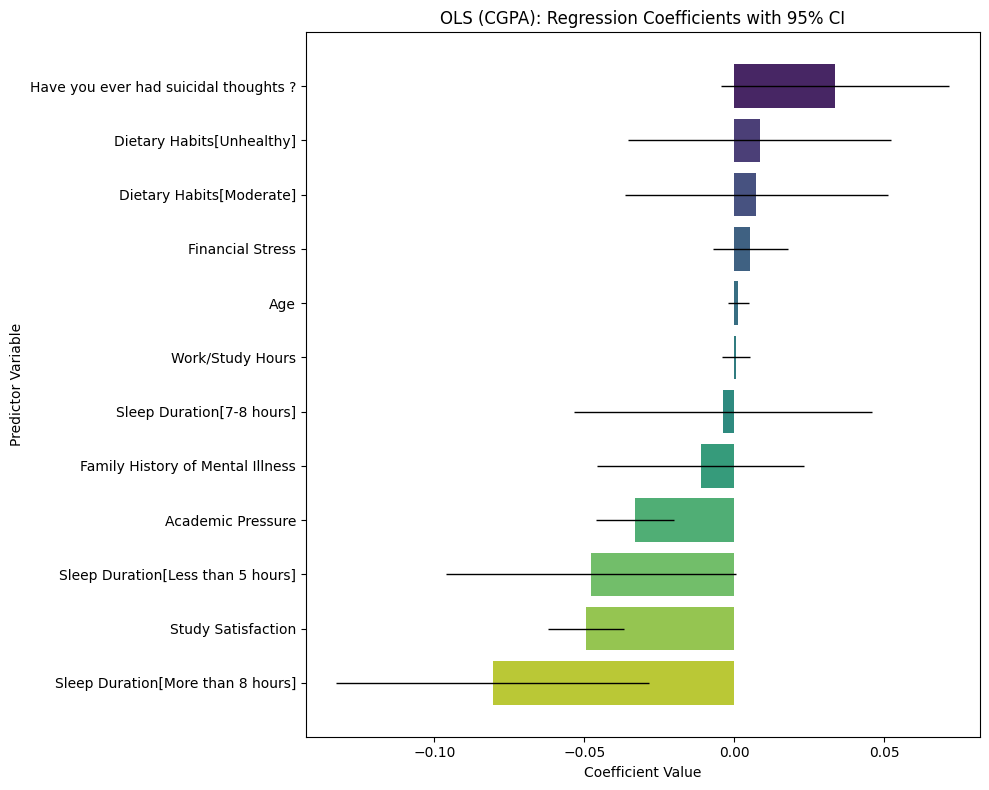

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

coefs_cgpa    = cgpa_ols_results.params
conf_int_cgpa = cgpa_ols_results.conf_int(alpha=0.05)

coef_df_cgpa = pd.DataFrame({
    'predictor':  coefs_cgpa.index,
    'coefficient': coefs_cgpa.values,
    'lower_ci':   conf_int_cgpa.iloc[:, 0],
    'upper_ci':   conf_int_cgpa.iloc[:, 1],
}).query("predictor != 'intercept'").sort_values('coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='coefficient', y='predictor', data=coef_df_cgpa,
            palette='viridis', hue='predictor', legend=False, ax=ax)
for _, row in coef_df_cgpa.iterrows():
    ax.hlines(row['predictor'], row['lower_ci'], row['upper_ci'],
              color='black', linewidth=1)
ax.set_title('OLS (CGPA): Regression Coefficients with 95% CI')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Variable')
plt.tight_layout()
plt.show()


### Residual Analysis — OLS (CGPA)

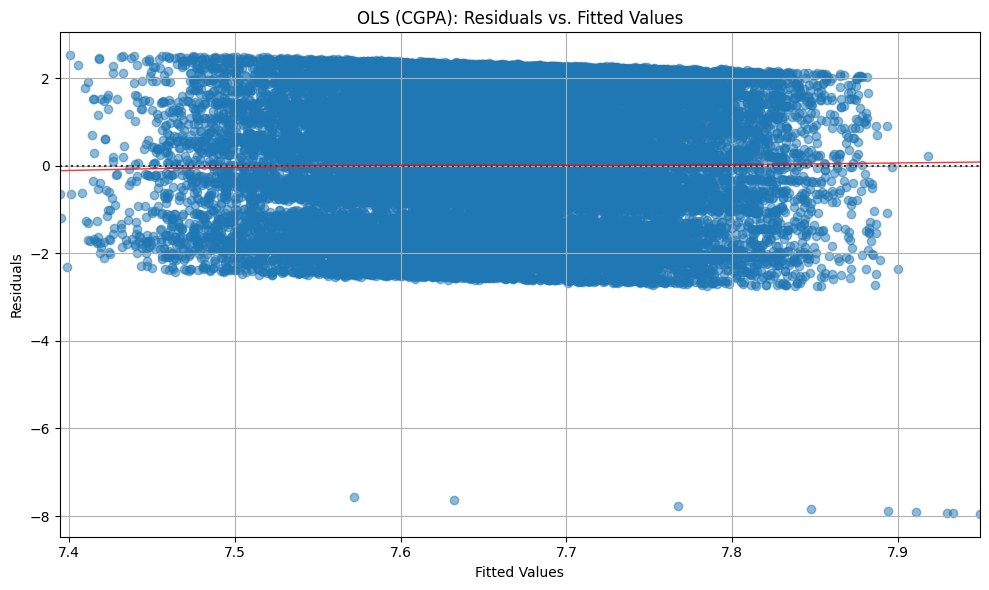

In [164]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.residplot(x=cgpa_ols_results.fittedvalues, y=cgpa_ols_results.resid,
              lowess=True, ax=ax,
              scatter_kws={'alpha': 0.5},
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax.set_title('OLS (CGPA): Residuals vs. Fitted Values')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()


### Q-Q Plot — OLS (CGPA)

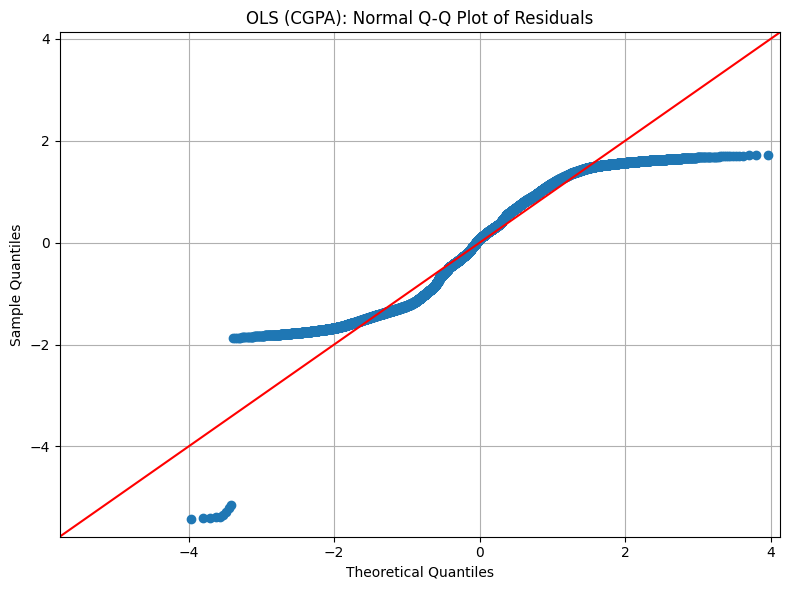

In [165]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(8, 6))
probplot_cgpa = sm.ProbPlot(cgpa_ols_results.resid, stats.t, fit=True)
probplot_cgpa.qqplot(line='45', ax=ax)
ax.set_title('OLS (CGPA): Normal Q-Q Plot of Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()


### Cross-Validation — OLS (CGPA)

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X_cgpa_train, X_cgpa_test, y_cgpa_train, y_cgpa_test = train_test_split(
    X_cgpa, y_cgpa, test_size=0.3, random_state=42
)

cgpa_ols_cv = sm.OLS(y_cgpa_train, X_cgpa_train).fit()
cgpa_ols_preds = cgpa_ols_cv.predict(X_cgpa_test)

cgpa_ols_mse  = mean_squared_error(y_cgpa_test, cgpa_ols_preds)
cgpa_ols_rmse = np.sqrt(cgpa_ols_mse)
cgpa_ols_mae  = mean_absolute_error(y_cgpa_test, cgpa_ols_preds)
cgpa_ols_r2   = r2_score(y_cgpa_test, cgpa_ols_preds)

print("OLS (CGPA) — Cross-Validation Metrics (Test Set):\n")
print(f"  R-squared : {cgpa_ols_r2:.4f}")
print(f"  MSE       : {cgpa_ols_mse:.4f}")
print(f"  RMSE      : {cgpa_ols_rmse:.4f}")
print(f"  MAE       : {cgpa_ols_mae:.4f}")


OLS (CGPA) — Cross-Validation Metrics (Test Set):

  R-squared : 0.0020
  MSE       : 2.1595
  RMSE      : 1.4695
  MAE       : 1.2723


## Feature Scaling for Penalised Models (CGPA)

In [167]:
X_cgpa_for_pen = X_cgpa.drop(columns=['intercept'])

Xs_cgpa   = X_cgpa_for_pen - X_cgpa_for_pen.mean(0).to_numpy()[None, :]
Xscale_cgpa = X_cgpa_for_pen.std(0).to_numpy().copy()
Xscale_cgpa[Xscale_cgpa == 0] = 1          # guard zero-variance columns
Xs_cgpa   = Xs_cgpa / Xscale_cgpa[None, :]

lambdas_cgpa = 10**np.linspace(8, -2, 100) / y_cgpa.std()
print("Scaled feature matrix shape:", Xs_cgpa.shape)


Scaled feature matrix shape: (27868, 12)


C:\Users\archa\AppData\Local\Temp\ipykernel_11008\147276328.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  Xs_cgpa   = X_cgpa_for_pen - X_cgpa_for_pen.mean(0).to_numpy()[None, :]
C:\Users\archa\AppData\Local\Temp\ipykernel_11008\147276328.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  Xscale_cgpa = X_cgpa_for_pen.std(0).to_numpy().copy()


## Ridge Regression (CGPA target)

In [168]:
from sklearn.linear_model import RidgeCV
import sklearn.linear_model as skl

alphas_cgpa = 10**np.linspace(-2, 8, 100)

cgpa_ridge_cv = RidgeCV(alphas=alphas_cgpa, store_cv_results=True,
                        scoring='neg_mean_squared_error')
cgpa_ridge_cv.fit(Xs_cgpa, y_cgpa)

print(f"Optimal Ridge alpha (CGPA): {cgpa_ridge_cv.alpha_:.4f}")


Optimal Ridge alpha (CGPA): 3593.8137


d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.469e+05, tolerance: 1.694e+02
  model = cd_fast.enet_coordinate_descent_gram(
d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regula

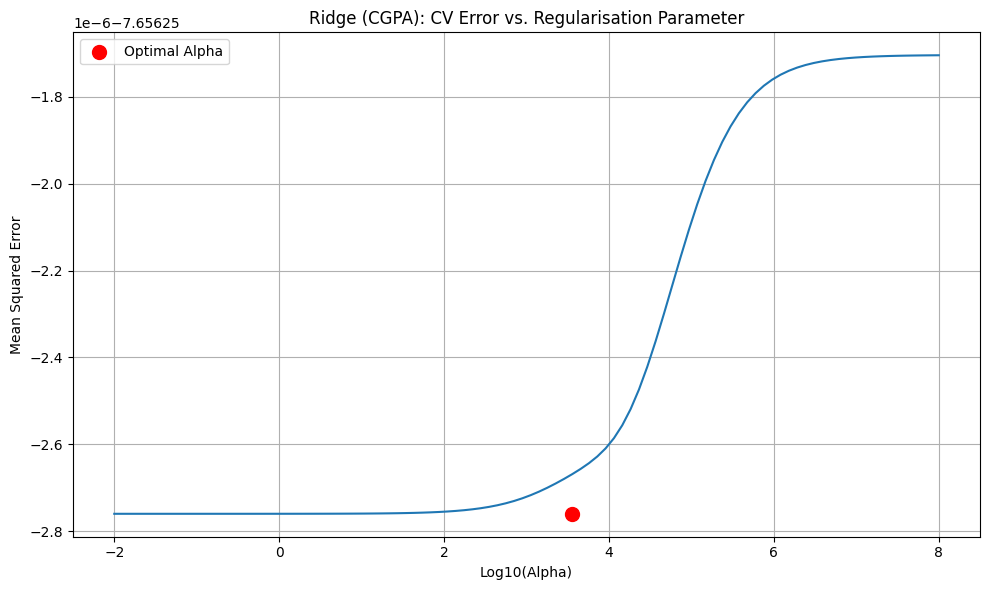

In [169]:
# Ridge regularisation path (CGPA)
soln_array_cgpa = skl.ElasticNet.path(
    Xs_cgpa, y_cgpa, l1_ratio=0., alphas=lambdas_cgpa
)[1]

fig, ax = plt.subplots(figsize=(10, 6))
mse_ridge_cgpa = -cgpa_ridge_cv.cv_results_.mean(axis=0)
ax.plot(np.log10(cgpa_ridge_cv.alphas), mse_ridge_cgpa)
ax.scatter(np.log10(cgpa_ridge_cv.alpha_), min(mse_ridge_cgpa),
           color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)'); ax.set_ylabel('Mean Squared Error')
ax.set_title('Ridge (CGPA): CV Error vs. Regularisation Parameter')
ax.grid(True); ax.legend(); plt.tight_layout(); plt.show()


In [170]:
optimal_cgpa_ridge = skl.Ridge(alpha=cgpa_ridge_cv.alpha_)
optimal_cgpa_ridge.fit(Xs_cgpa, y_cgpa)

cgpa_ridge_coef = pd.DataFrame({
    'Feature':     Xs_cgpa.columns,
    'Coefficient': optimal_cgpa_ridge.coef_
}).sort_values('Coefficient', ascending=False)

print(f"Ridge (CGPA) Coefficients  (alpha={cgpa_ridge_cv.alpha_:.4f}):")
display(cgpa_ridge_coef)


Ridge (CGPA) Coefficients  (alpha=3593.8137):


,Feature,Coefficient
8,Have you ever had suicidal thoughts ?,0.013604
10,Financial Stress,0.006897
0,Age,0.006131
7,Dietary Habits[Unhealthy],0.003014
6,Dietary Habits[Moderate],0.002804
3,Sleep Duration[7-8 hours],0.002552
9,Work/Study Hours,0.002434
11,Family History of Mental Illness,-0.005007
4,Sleep Duration[Less than 5 hours],-0.015933
5,Sleep Duration[More than 8 hours],-0.026466


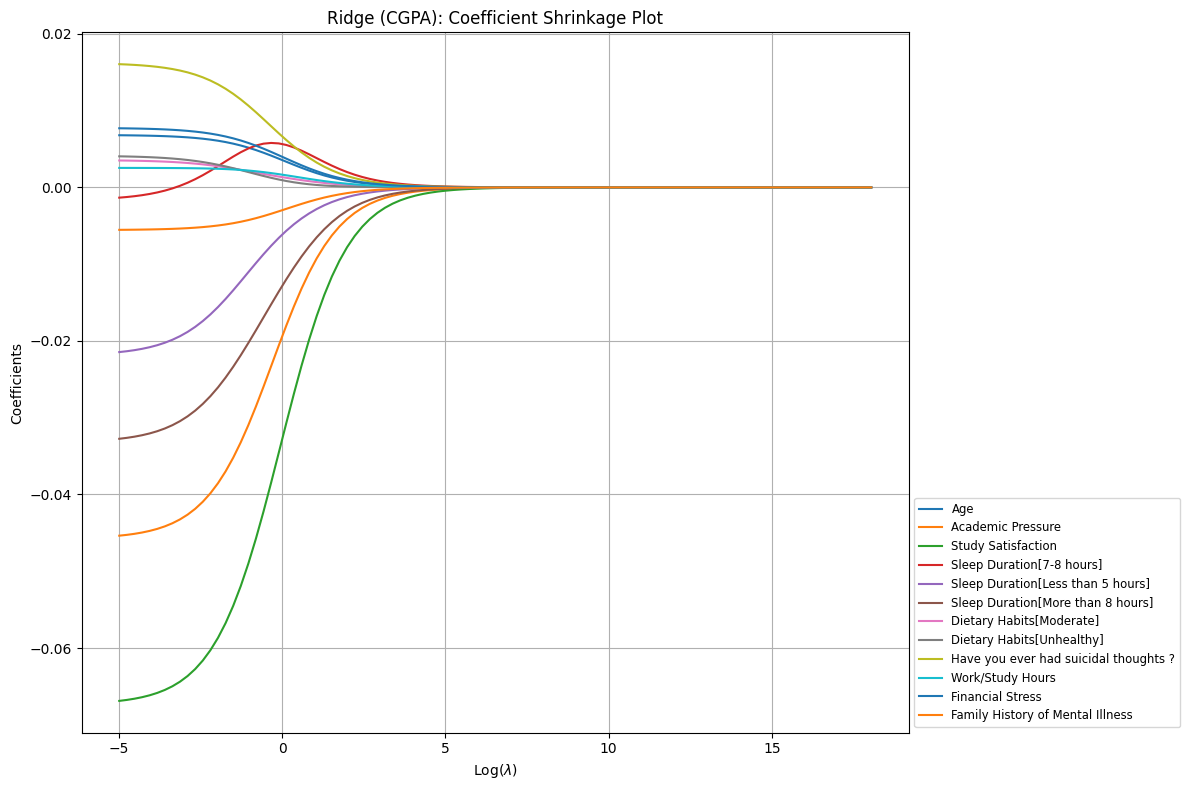

In [171]:
# Ridge coefficient shrinkage plot (CGPA)
feature_names_cgpa = Xs_cgpa.columns

fig, ax = plt.subplots(figsize=(12, 8))
for i in range(soln_array_cgpa.shape[0]):
    ax.plot(np.log(lambdas_cgpa), soln_array_cgpa[i], label=feature_names_cgpa[i])
ax.set_xlabel(r'Log($\lambda$)'); ax.set_ylabel('Coefficients')
ax.set_title('Ridge (CGPA): Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=1, fontsize='small')
ax.grid(True); plt.tight_layout(); plt.show()


## Lasso Regression (CGPA target)

In [172]:
from sklearn.linear_model import LassoCV

cgpa_lasso_cv = LassoCV(alphas=None, cv=10, random_state=42,
                        n_jobs=-1, max_iter=10000)
cgpa_lasso_cv.fit(Xs_cgpa, y_cgpa)

print(f"Optimal Lasso alpha (CGPA): {cgpa_lasso_cv.alpha_:.4f}")


d:\Programming\Classwork\STAT4210\STAT-4210-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Optimal Lasso alpha (CGPA): 0.0060


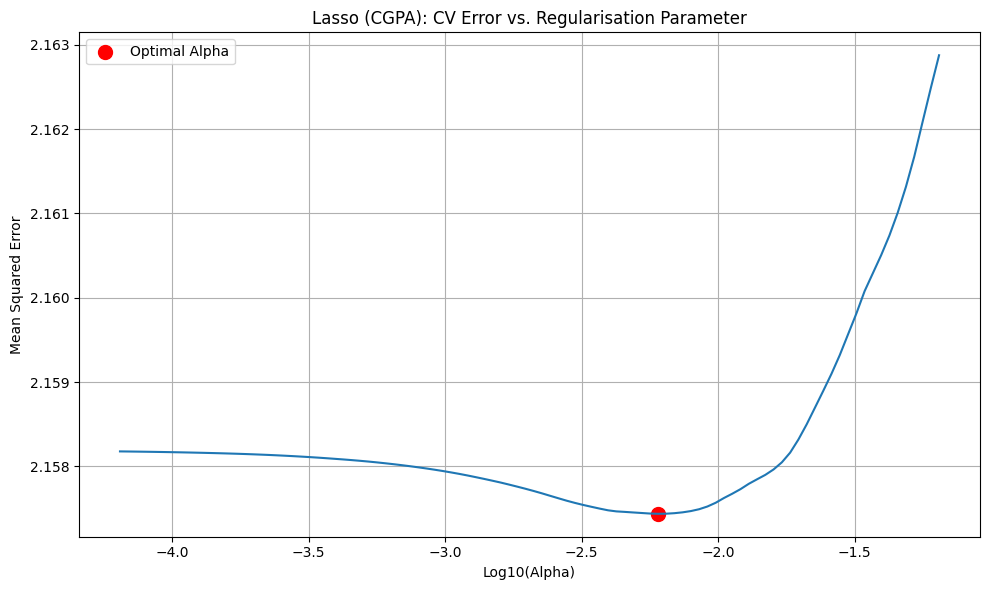

In [173]:
mse_lasso_cgpa = cgpa_lasso_cv.mse_path_.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(cgpa_lasso_cv.alphas_), mse_lasso_cgpa)
ax.scatter(np.log10(cgpa_lasso_cv.alpha_), min(mse_lasso_cgpa),
           color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)'); ax.set_ylabel('Mean Squared Error')
ax.set_title('Lasso (CGPA): CV Error vs. Regularisation Parameter')
ax.grid(True); ax.legend(); plt.tight_layout(); plt.show()


In [174]:
optimal_cgpa_lasso = skl.Lasso(alpha=cgpa_lasso_cv.alpha_, max_iter=10000)
optimal_cgpa_lasso.fit(Xs_cgpa, y_cgpa)

cgpa_lasso_coef = pd.DataFrame({
    'Feature':     Xs_cgpa.columns,
    'Coefficient': optimal_cgpa_lasso.coef_
}).sort_values('Coefficient', ascending=False)

print(f"Lasso (CGPA) non-zero Coefficients  (alpha={cgpa_lasso_cv.alpha_:.4f}):")
display(cgpa_lasso_coef[cgpa_lasso_coef['Coefficient'] != 0])


Lasso (CGPA) non-zero Coefficients  (alpha=0.0060):


,Feature,Coefficient
8,Have you ever had suicidal thoughts ?,0.009372
10,Financial Stress,0.001950
0,Age,0.000024
4,Sleep Duration[Less than 5 hours],-0.011926
5,Sleep Duration[More than 8 hours],-0.023611
1,Academic Pressure,-0.036687
2,Study Satisfaction,-0.061401


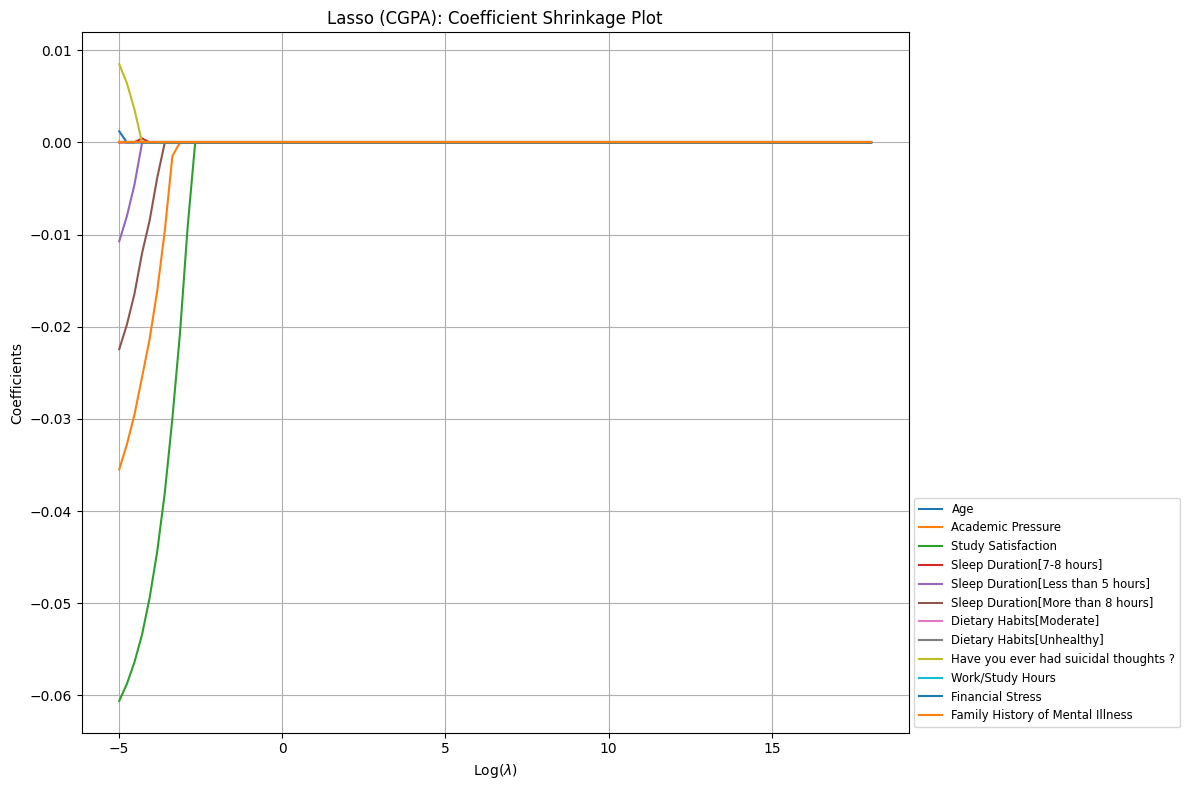

In [175]:
# Lasso coefficient shrinkage plot (CGPA)
soln_array_lasso_cgpa = skl.ElasticNet.path(
    Xs_cgpa, y_cgpa, l1_ratio=1., alphas=lambdas_cgpa
)[1]

fig, ax = plt.subplots(figsize=(12, 8))
for i in range(soln_array_lasso_cgpa.shape[0]):
    ax.plot(np.log(lambdas_cgpa), soln_array_lasso_cgpa[i], label=feature_names_cgpa[i])
ax.set_xlabel(r'Log($\lambda$)'); ax.set_ylabel('Coefficients')
ax.set_title('Lasso (CGPA): Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=1, fontsize='small')
ax.grid(True); plt.tight_layout(); plt.show()


## Elastic Net Regression (CGPA target)

In [176]:
from sklearn.linear_model import ElasticNetCV

l1_ratios_cgpa = np.linspace(0.01, 1.0, 10)

cgpa_enet_cv = ElasticNetCV(l1_ratio=l1_ratios_cgpa, cv=10,
                            random_state=42, n_jobs=-1, max_iter=10000)
cgpa_enet_cv.fit(Xs_cgpa, y_cgpa)

print(f"Optimal Elastic Net alpha   (CGPA): {cgpa_enet_cv.alpha_:.4f}")
print(f"Optimal Elastic Net l1_ratio(CGPA): {cgpa_enet_cv.l1_ratio_:.4f}")


Optimal Elastic Net alpha   (CGPA): 0.0060
Optimal Elastic Net l1_ratio(CGPA): 1.0000


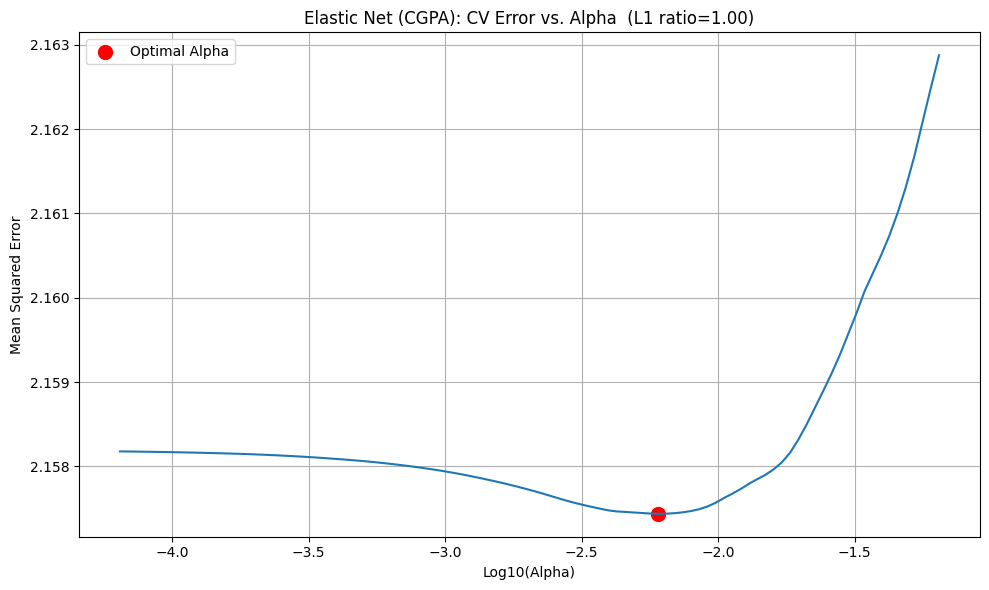

In [177]:
opt_l1_idx_cgpa = np.argmin(np.abs(cgpa_enet_cv.l1_ratio - cgpa_enet_cv.l1_ratio_))
mse_enet_cgpa   = cgpa_enet_cv.mse_path_[opt_l1_idx_cgpa, :].mean(axis=1)
alphas_enet_cgpa = cgpa_enet_cv.alphas_[opt_l1_idx_cgpa]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(alphas_enet_cgpa), mse_enet_cgpa)
ax.scatter(np.log10(cgpa_enet_cv.alpha_), min(mse_enet_cgpa),
           color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)'); ax.set_ylabel('Mean Squared Error')
ax.set_title(f'Elastic Net (CGPA): CV Error vs. Alpha  (L1 ratio={cgpa_enet_cv.l1_ratio_:.2f})')
ax.grid(True); ax.legend(); plt.tight_layout(); plt.show()


In [178]:
optimal_cgpa_enet = skl.ElasticNet(alpha=cgpa_enet_cv.alpha_,
                                   l1_ratio=cgpa_enet_cv.l1_ratio_,
                                   max_iter=10000)
optimal_cgpa_enet.fit(Xs_cgpa, y_cgpa)

cgpa_enet_coef = pd.DataFrame({
    'Feature':     Xs_cgpa.columns,
    'Coefficient': optimal_cgpa_enet.coef_
}).sort_values('Coefficient', ascending=False)

print(f"Elastic Net (CGPA) non-zero Coefficients "
      f"(alpha={cgpa_enet_cv.alpha_:.4f}, l1_ratio={cgpa_enet_cv.l1_ratio_:.4f}):")
display(cgpa_enet_coef[cgpa_enet_coef['Coefficient'] != 0])


Elastic Net (CGPA) non-zero Coefficients (alpha=0.0060, l1_ratio=1.0000):


,Feature,Coefficient
8,Have you ever had suicidal thoughts ?,0.009372
10,Financial Stress,0.001950
0,Age,0.000024
4,Sleep Duration[Less than 5 hours],-0.011926
5,Sleep Duration[More than 8 hours],-0.023611
1,Academic Pressure,-0.036687
2,Study Satisfaction,-0.061401


## Model Comparison (CGPA target)

In [179]:
# ── Collect predictions from each model on the same 70/30 split ──────────────
X_cgpa_s_train, X_cgpa_s_test, y_cgpa_s_train, y_cgpa_s_test = train_test_split(
    Xs_cgpa, y_cgpa, test_size=0.3, random_state=42
)

def eval_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'R2':   r2_score(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
    }

# OLS (re-fit on scaled features for fair comparison)
cgpa_ols_s = sm.OLS(y_cgpa_s_train,
                    sm.add_constant(X_cgpa_s_train)).fit()
ols_preds_s = cgpa_ols_s.predict(sm.add_constant(X_cgpa_s_test))

# Ridge
ridge_tmp = skl.Ridge(alpha=cgpa_ridge_cv.alpha_).fit(X_cgpa_s_train, y_cgpa_s_train)
ridge_preds_s = ridge_tmp.predict(X_cgpa_s_test)

# Lasso
lasso_tmp = skl.Lasso(alpha=cgpa_lasso_cv.alpha_, max_iter=10000).fit(X_cgpa_s_train, y_cgpa_s_train)
lasso_preds_s = lasso_tmp.predict(X_cgpa_s_test)

# Elastic Net
enet_tmp = skl.ElasticNet(alpha=cgpa_enet_cv.alpha_, l1_ratio=cgpa_enet_cv.l1_ratio_,
                          max_iter=10000).fit(X_cgpa_s_train, y_cgpa_s_train)
enet_preds_s = enet_tmp.predict(X_cgpa_s_test)

cgpa_perf = pd.DataFrame([
    eval_metrics('OLS',         y_cgpa_s_test, ols_preds_s),
    eval_metrics('Ridge',       y_cgpa_s_test, ridge_preds_s),
    eval_metrics('Lasso',       y_cgpa_s_test, lasso_preds_s),
    eval_metrics('Elastic Net', y_cgpa_s_test, enet_preds_s),
]).set_index('Model')

print("CGPA Model Performance Metrics (Test Set):")
display(cgpa_perf.round(4).sort_values('RMSE'))


CGPA Model Performance Metrics (Test Set):


,R2,MSE,RMSE,MAE
Model,,,,
Elastic Net,0.0023,2.1588,1.4693,1.2722
Lasso,0.0023,2.1588,1.4693,1.2722
Ridge,0.0021,2.1593,1.4694,1.2725
OLS,0.0020,2.1595,1.4695,1.2723


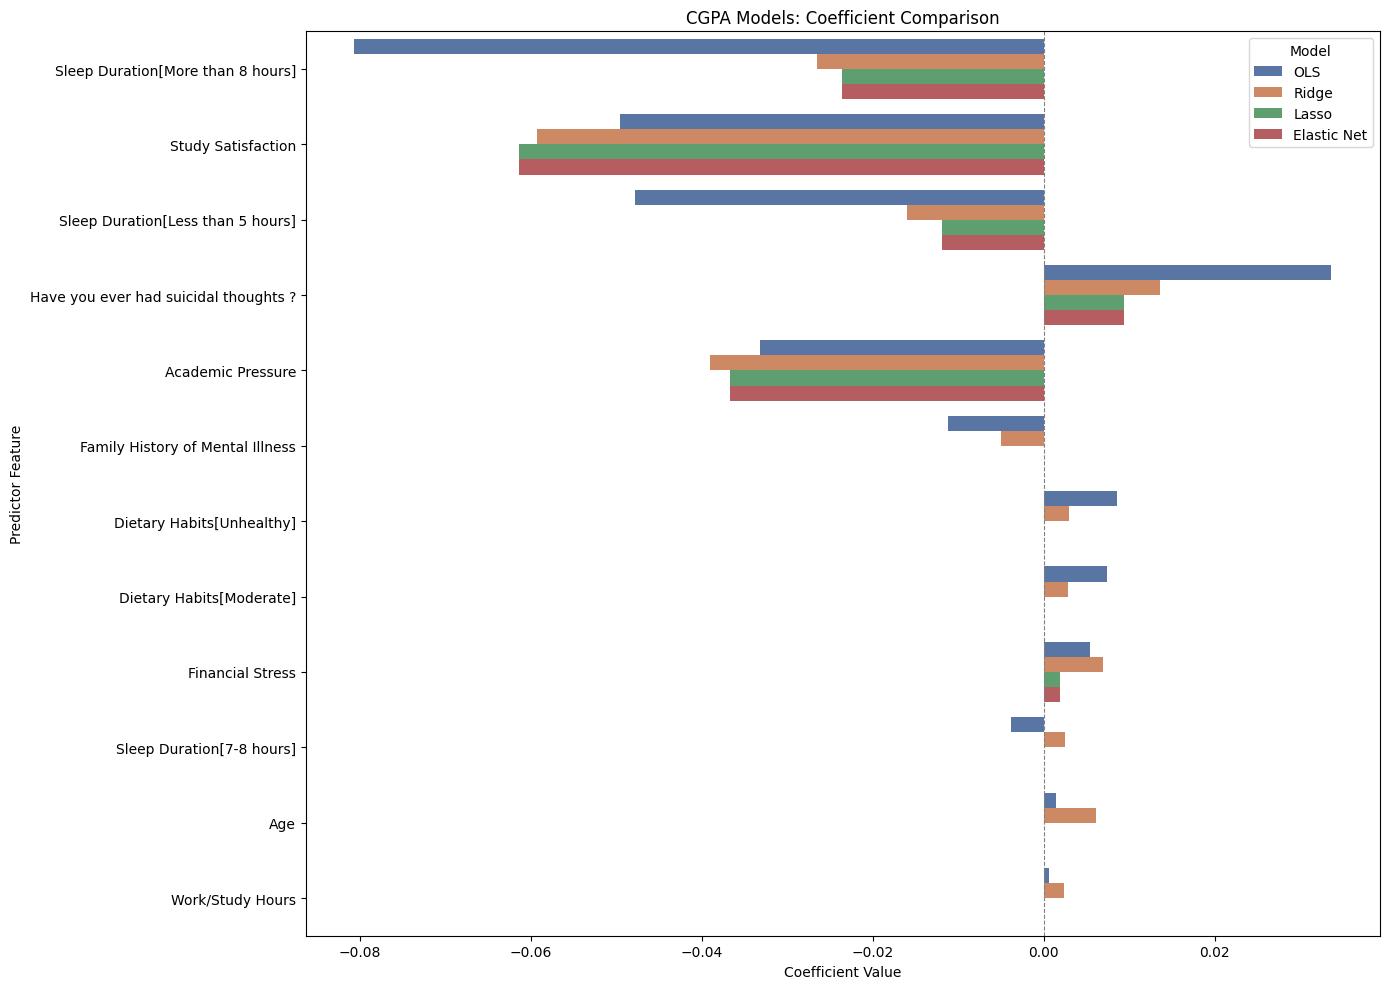

In [180]:
# Coefficient comparison plot across all four CGPA models
ols_coefs_cgpa_aligned = cgpa_ols_results.params[X_cgpa_for_pen.columns]

all_coefs_cgpa = pd.concat([
    pd.DataFrame({'Feature': ols_coefs_cgpa_aligned.index,
                  'Coefficient': ols_coefs_cgpa_aligned.values, 'Model': 'OLS'}),
    pd.DataFrame({'Feature': cgpa_ridge_coef['Feature'],
                  'Coefficient': cgpa_ridge_coef['Coefficient'], 'Model': 'Ridge'}),
    pd.DataFrame({'Feature': cgpa_lasso_coef['Feature'],
                  'Coefficient': cgpa_lasso_coef['Coefficient'], 'Model': 'Lasso'}),
    pd.DataFrame({'Feature': cgpa_enet_coef['Feature'],
                  'Coefficient': cgpa_enet_coef['Coefficient'], 'Model': 'Elastic Net'}),
])

sorted_features_cgpa = (
    ols_coefs_cgpa_aligned.abs()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(x='Coefficient', y='Feature', hue='Model',
            data=all_coefs_cgpa, palette='deep',
            order=sorted_features_cgpa, ax=ax)
ax.set_title('CGPA Models: Coefficient Comparison')
ax.set_xlabel('Coefficient Value'); ax.set_ylabel('Predictor Feature')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Model')
plt.tight_layout()
plt.show()


In [181]:
print(cgpa_terms)
print(terms)

Index(['Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness'],
      dtype='str')
Index(['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='str')


Pairplot: Depression Model


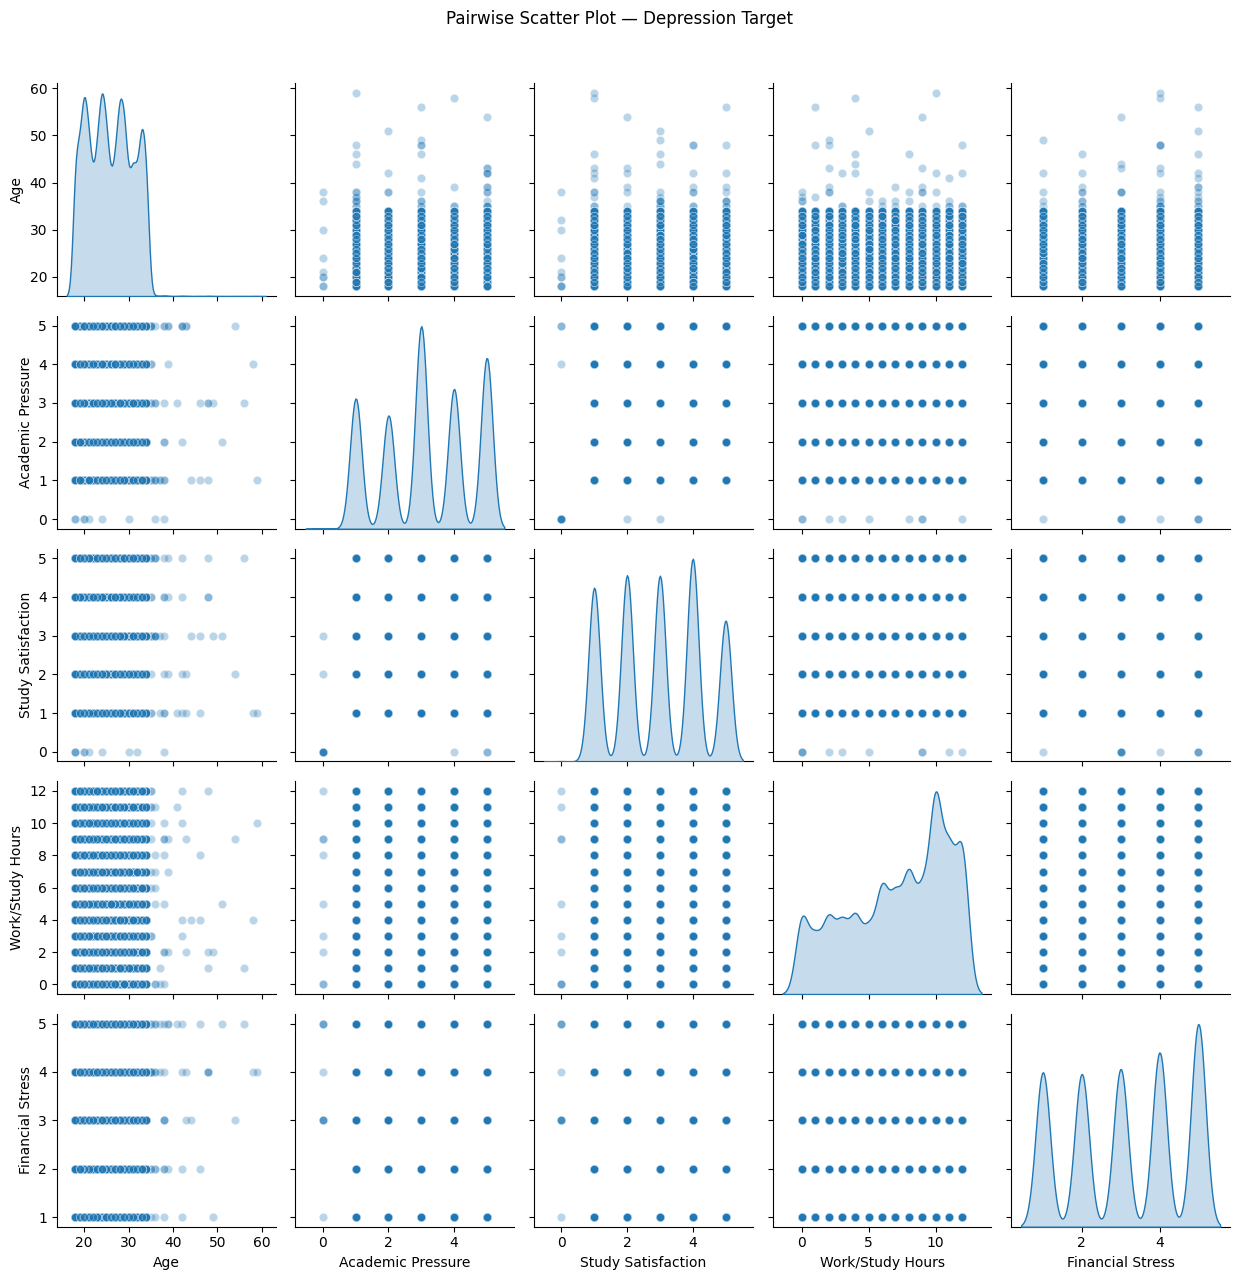

Pairplot: CGPA Model


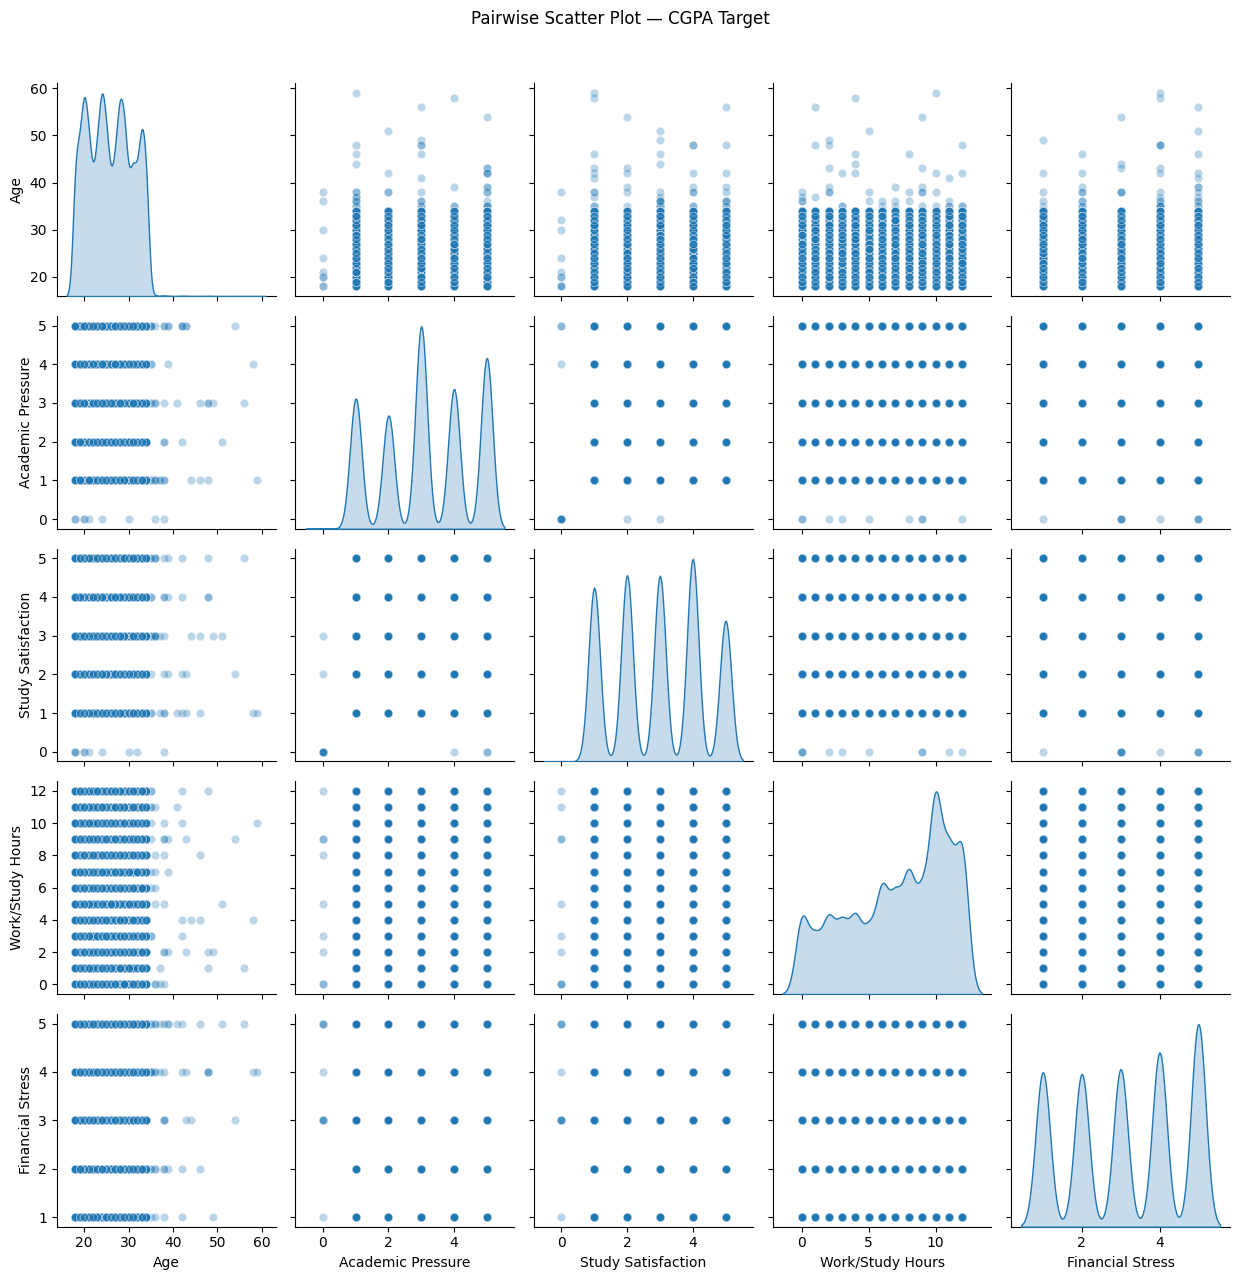

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Shared preprocessing (same as your notebook) ──────────────────────────
SD = StudentDepression.copy()
SD = SD[(SD['Sleep Duration'] != 'Others') & (SD['Dietary Habits'] != 'Others')]
SD = SD.dropna()

# ── Numeric columns relevant to both models ───────────────────────────────
# numeric_cols = [
#     'Age', 'Academic Pressure', 'Study Satisfaction',
#     'Work/Study Hours', 'Financial Stress', 'CGPA', 'Depression'
# ]
numeric_cols = cgpa_terms.tolist()
# ── Pairplot — Depression model ───────────────────────────────────────────
print("Pairplot: Depression Model")
dep_cols = [c for c in numeric_cols if c != 'CGPA']  # CGPA excluded as predictor
sns.pairplot(SD[dep_cols], diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pairwise Scatter Plot — Depression Target', y=1.02)
plt.tight_layout()
plt.show()

# ── Pairplot — CGPA model ─────────────────────────────────────────────────
print("Pairplot: CGPA Model")
cgpa_cols = [c for c in numeric_cols if c != 'Depression']  # Depression excluded
sns.pairplot(SD[cgpa_cols], diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pairwise Scatter Plot — CGPA Target', y=1.02)
plt.tight_layout()
plt.show()

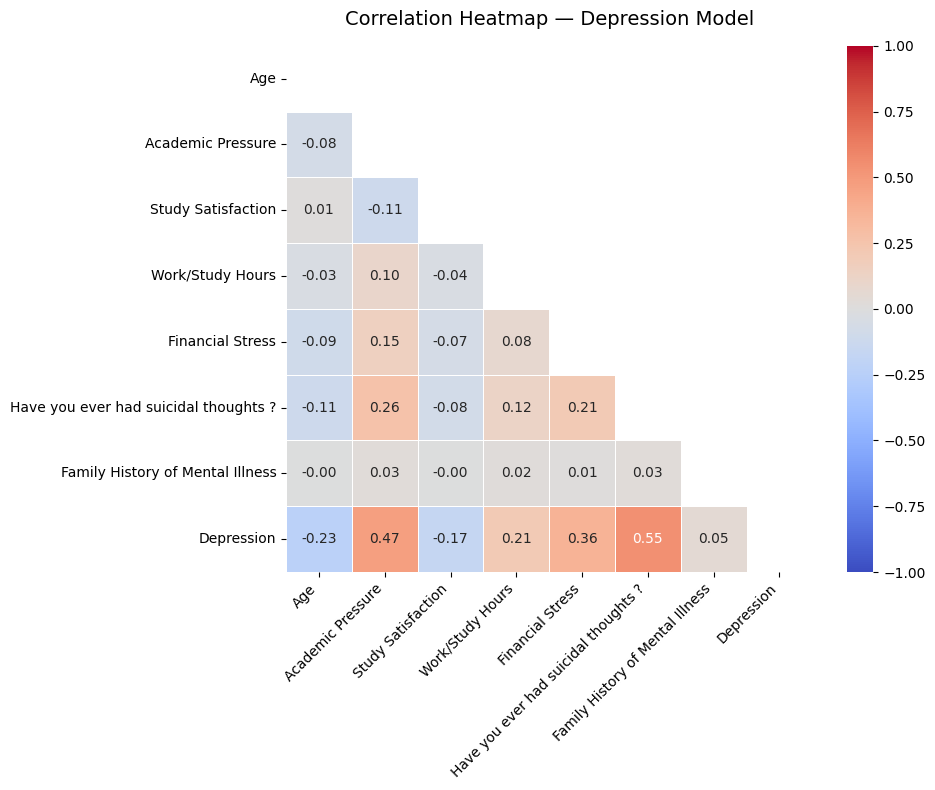

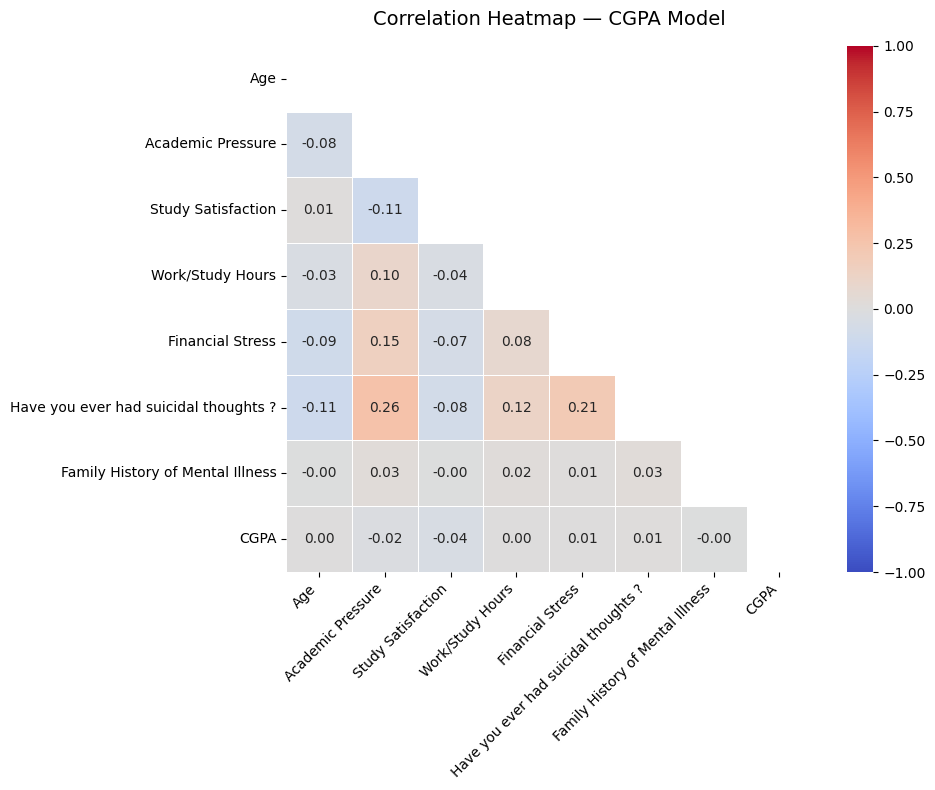

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── Shared preprocessing ──────────────────────────────────────────────────
SD = StudentDepression.copy()
SD = SD[(SD['Sleep Duration'] != 'Others') & (SD['Dietary Habits'] != 'Others')]
SD['Have you ever had suicidal thoughts ?'] = SD['Have you ever had suicidal thoughts ?'].map({'Yes': 1.0, 'No': 0.0})
SD['Family History of Mental Illness'] = SD['Family History of Mental Illness'].map({'Yes': 1.0, 'No': 0.0})
SD = SD.dropna()

# ── Features for each model ───────────────────────────────────────────────
depression_cols = [
    'Age', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours',
    'Financial Stress', 'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness', 'Depression'
]

cgpa_cols = [
    'Age', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours',
    'Financial Stress', 'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness', 'CGPA'
]

# ── Helper to plot a heatmap ──────────────────────────────────────────────
def plot_heatmap(df, cols, title):
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        square=True,
        ax=ax
    )
    ax.set_title(title, fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ── Plot both heatmaps ────────────────────────────────────────────────────
plot_heatmap(SD, depression_cols, 'Correlation Heatmap — Depression Model')
plot_heatmap(SD, cgpa_cols,       'Correlation Heatmap — CGPA Model')

In [184]:
import numpy as np

# ── Helper: compute AIC & BIC for sklearn-style models ──────────────────────
def aic_bic_sklearn(model, X, y):
    """Compute AIC and BIC for a fitted sklearn linear model."""
    y_pred = model.predict(X)
    n = len(y)
    resid = y - y_pred
    sse = np.sum(resid ** 2)
    sigma2 = sse / n                          # MLE variance estimate
    ll = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)  # log-likelihood

    # number of non-zero coefficients + intercept
    k = np.sum(model.coef_ != 0) + 1

    aic = 2 * k - 2 * ll
    bic = k * np.log(n) - 2 * ll
    return aic, bic


# ── 1. OLS — statsmodels gives AIC/BIC directly ─────────────────────────────
print("=== OLS (CGPA) ===")
print(f"  AIC : {cgpa_ols_results.aic:.4f}")
print(f"  BIC : {cgpa_ols_results.bic:.4f}")

# ── 2. Ridge ─────────────────────────────────────────────────────────────────
ridge_aic, ridge_bic = aic_bic_sklearn(optimal_cgpa_ridge, Xs_cgpa, y_cgpa)
print("\n=== Ridge (CGPA) ===")
print(f"  AIC : {ridge_aic:.4f}")
print(f"  BIC : {ridge_bic:.4f}")

# ── 3. Lasso ─────────────────────────────────────────────────────────────────
lasso_aic, lasso_bic = aic_bic_sklearn(optimal_cgpa_lasso, Xs_cgpa, y_cgpa)
print("\n=== Lasso (CGPA) ===")
print(f"  AIC : {lasso_aic:.4f}")
print(f"  BIC : {lasso_bic:.4f}")

# ── 4. Elastic Net ───────────────────────────────────────────────────────────
enet_aic, enet_bic = aic_bic_sklearn(optimal_cgpa_enet, Xs_cgpa, y_cgpa)
print("\n=== Elastic Net (CGPA) ===")
print(f"  AIC : {enet_aic:.4f}")
print(f"  BIC : {enet_bic:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
aic_bic_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'AIC':   [cgpa_ols_results.aic, ridge_aic, lasso_aic, enet_aic],
    'BIC':   [cgpa_ols_results.bic, ridge_bic, lasso_bic, enet_bic],
}).set_index('Model')

print("\n=== AIC / BIC Summary (CGPA models) ===")
display(aic_bic_df.round(4).sort_values('AIC'))

=== OLS (CGPA) ===
  AIC : 100515.4921
  BIC : 100622.5501

=== Ridge (CGPA) ===
  AIC : 100517.2607
  BIC : 100624.3188

=== Lasso (CGPA) ===
  AIC : 100510.2570
  BIC : 100576.1389

=== Elastic Net (CGPA) ===
  AIC : 100510.2570
  BIC : 100576.1389

=== AIC / BIC Summary (CGPA models) ===


,AIC,BIC
Model,,
Elastic Net,100510.2570,100576.1389
Lasso,100510.2570,100576.1389
OLS,100515.4921,100622.5501
Ridge,100517.2607,100624.3188


In [185]:
# ── Mallows' Cp ──────────────────────────────────────────────────────────────
# Cp = (SSE_p / sigma2_full) - n + 2k
# where sigma2_full = MSE from the full OLS model (used as variance estimate)

# Full model variance estimate (from OLS)
n_cgpa = len(y_cgpa)
sigma2_full = cgpa_ols_results.mse_resid  # OLS residual MSE (unbiased estimate)

def mallows_cp(model_preds, k, n, sigma2_full):
    sse = np.sum((y_cgpa - model_preds) ** 2)
    cp = (sse / sigma2_full) - n + 2 * k
    return cp

# OLS
ols_k   = len(cgpa_ols_results.params)           # number of params incl. intercept
ols_cp  = mallows_cp(cgpa_ols_results.fittedvalues, ols_k, n_cgpa, sigma2_full)

# Ridge
ridge_k  = np.sum(optimal_cgpa_ridge.coef_ != 0) + 1
ridge_cp = mallows_cp(optimal_cgpa_ridge.predict(Xs_cgpa), ridge_k, n_cgpa, sigma2_full)

# Lasso
lasso_k  = np.sum(optimal_cgpa_lasso.coef_ != 0) + 1
lasso_cp = mallows_cp(optimal_cgpa_lasso.predict(Xs_cgpa), lasso_k, n_cgpa, sigma2_full)

# Elastic Net
enet_k  = np.sum(optimal_cgpa_enet.coef_ != 0) + 1
enet_cp = mallows_cp(optimal_cgpa_enet.predict(Xs_cgpa), enet_k, n_cgpa, sigma2_full)

# ── Summary ──────────────────────────────────────────────────────────────────
cp_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'k (params)': [ols_k, ridge_k, lasso_k, enet_k],
    'Cp': [ols_cp, ridge_cp, lasso_cp, enet_cp],
}).set_index('Model')

print("=== Mallows' Cp Summary (CGPA models) ===")
display(cp_df.round(4).sort_values('Cp'))

=== Mallows' Cp Summary (CGPA models) ===


,k (params),Cp
Model,,
Elastic Net,8,7.7631
Lasso,8,7.7631
OLS,13,13.0000
Ridge,13,14.7679


In [187]:
# ══════════════════════════════════════════════════════════════════
#  AIC / BIC / Mallows' Cp  —  Depression & CGPA Models
# ══════════════════════════════════════════════════════════════════

import numpy as np

# ── CGPA: AIC & BIC ───────────────────────────────────────────────
def aic_bic_sklearn(model, X, y):
    y_pred  = model.predict(X)
    n       = len(y)
    sse     = np.sum((y - y_pred) ** 2)
    sigma2  = sse / n
    ll      = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    k       = np.sum(model.coef_ != 0) + 1
    return 2 * k - 2 * ll, k * np.log(n) - 2 * ll

cgpa_ridge_aic, cgpa_ridge_bic = aic_bic_sklearn(optimal_cgpa_ridge, Xs_cgpa, y_cgpa)
cgpa_lasso_aic, cgpa_lasso_bic = aic_bic_sklearn(optimal_cgpa_lasso, Xs_cgpa, y_cgpa)
cgpa_enet_aic,  cgpa_enet_bic  = aic_bic_sklearn(optimal_cgpa_enet,  Xs_cgpa, y_cgpa)

# ── CGPA: Mallows' Cp ─────────────────────────────────────────────
n_cgpa       = len(y_cgpa)
sigma2_cgpa  = cgpa_ols_results.mse_resid   # full-model variance estimate

def cp_cgpa(preds, k):
    return (np.sum((y_cgpa - preds) ** 2) / sigma2_cgpa) - n_cgpa + 2 * k

cgpa_ols_cp   = cp_cgpa(cgpa_ols_results.fittedvalues,          len(cgpa_ols_results.params))
cgpa_ridge_cp = cp_cgpa(optimal_cgpa_ridge.predict(Xs_cgpa),    np.sum(optimal_cgpa_ridge.coef_ != 0) + 1)
cgpa_lasso_cp = cp_cgpa(optimal_cgpa_lasso.predict(Xs_cgpa),    np.sum(optimal_cgpa_lasso.coef_ != 0) + 1)
cgpa_enet_cp  = cp_cgpa(optimal_cgpa_enet.predict(Xs_cgpa),     np.sum(optimal_cgpa_enet.coef_  != 0) + 1)

# ── Build CGPA table ──────────────────────────────────────────────
cgpa_sel = pd.DataFrame({
    'Model':  ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'AIC':    [cgpa_ols_results.aic, cgpa_ridge_aic, cgpa_lasso_aic, cgpa_enet_aic],
    'BIC':    [cgpa_ols_results.bic, cgpa_ridge_bic, cgpa_lasso_bic, cgpa_enet_bic],
    'Cp':     [cgpa_ols_cp,          cgpa_ridge_cp,  cgpa_lasso_cp,  cgpa_enet_cp],
}).set_index('Model')

# ── Build Depression table (already in performance_metrics) ───────
dep_sel = performance_metrics[['AIC', 'BIC', 'Cp']].copy()

# ══════════════════════════════════════════════════════════════════
#  Display side-by-side
# ══════════════════════════════════════════════════════════════════
from IPython.display import display, HTML

def styled_table(df, title):
    return (
        df.round(2)
          .sort_values('BIC')
          .style
          .set_caption(f"<b>{title}</b>")
          .format("{:,.2f}")
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '13px'), ('text-align', 'left'),
                         ('padding-bottom', '6px')]},
              {'selector': 'th',
               'props': [('text-align', 'center'), ('border-bottom', '1px solid #555'),
                         ('padding', '4px 12px')]},
              {'selector': 'td',
               'props': [('text-align', 'center'), ('padding', '3px 12px')]},
              {'selector': 'tr:last-child td',
               'props': [('border-bottom', '1px solid #555')]},
          ])
    )
cgpa_sel.index.name = None
dep_styled  = styled_table(dep_sel,  "Depression Models — AIC, BIC & Mallows' Cp").to_html()
cgpa_styled = styled_table(cgpa_sel, "CGPA Models — AIC, BIC & Mallows' Cp").to_html()

display(HTML(f"""
<div style="display:flex; gap:40px; align-items:flex-start;">
  <div>{dep_styled}</div>
  <div>{cgpa_styled}</div>
</div>
"""))

,AIC,BIC,Cp
OLS,"-59,734.21","-59,925.73",14.00
Ridge,"-59,736.19","-59,629.13",12.02
Lasso,"-59,735.99","-59,628.93",12.22
Elastic Net,"-59,735.99","-59,628.93",12.22
,AIC,BIC,Cp
Elastic Net,"100,510.26","100,576.14",7.76
Lasso,"100,510.26","100,576.14",7.76
OLS,"100,515.49","100,622.55",13.00
Ridge,"100,517.26","100,624.32",14.77


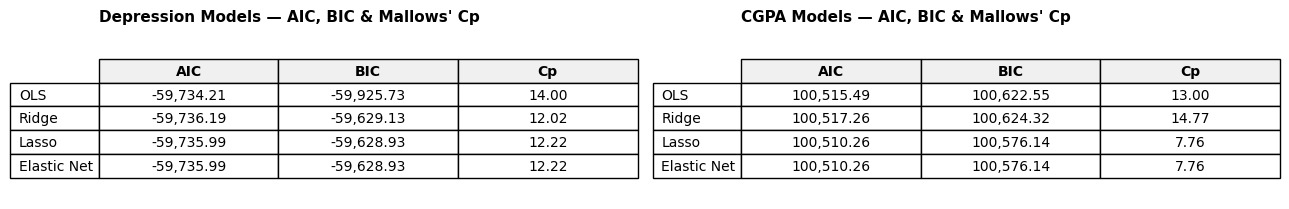

In [188]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Sort both tables in the same order ───────────────────────────
order = ['OLS', 'Ridge', 'Lasso', 'Elastic Net']

dep_sorted  = dep_sel.loc[order].round(2)
cgpa_sorted = cgpa_sel.loc[order].round(2)

# ── Render as image ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 2.2))
fig.patch.set_facecolor('white')

def draw_table(ax, df, title):
    ax.axis('off')
    col_labels = df.columns.tolist()
    row_labels  = df.index.tolist()
    cell_vals   = [[f"{v:,.2f}" for v in row] for row in df.values]

    tbl = ax.table(
        cellText   = cell_vals,
        rowLabels  = row_labels,
        colLabels  = col_labels,
        loc        = 'center',
        cellLoc    = 'center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)

    # Header row styling
    for col_idx in range(len(col_labels)):
        cell = tbl[0, col_idx]
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(fontweight='bold')

    # Row label styling
    for row_idx in range(1, len(row_labels) + 1):
        tbl[row_idx, -1].set_facecolor('white')  # row label bg

    ax.set_title(title, fontsize=11, fontweight='bold', pad=12, loc='left')

draw_table(axes[0], dep_sorted,  "Depression Models — AIC, BIC & Mallows' Cp")
draw_table(axes[1], cgpa_sorted, "CGPA Models — AIC, BIC & Mallows' Cp")

plt.tight_layout()
plt.savefig('model_selection_tables.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()